# **Name**: **Rajib Regmi**

# **UID:2438399**



---



#**Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.**

**Data Understanding, Analysis, Visualization and Cleaning:**

Before building models, analyze and understand the dataset by answering the following questions:

**• What does the dataset represent? Provide a brief description.**

    The dataset represents MRI brain scan images used for brain tumor classification.
    Its main objective is to classify brain MRI images into four different categories:

    Glioma Tumor
    Meningioma Tumor
    Pituitary Tumor
    Normal (No Tumor)




Extracting dataset …
Extraction complete.
Checking image integrity …
  ⚠ 28 corrupted file(s) found – removing them.
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_765.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_323.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_680.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_154.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_54.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_179.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/meningioma_tumor/M_440.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/pituitary_tumor/P_397.jpg
    Removed: /content/brain_tumor_data/Brain Tumor Classifcation/train/pituitary_tumor/P_160.jpg
    

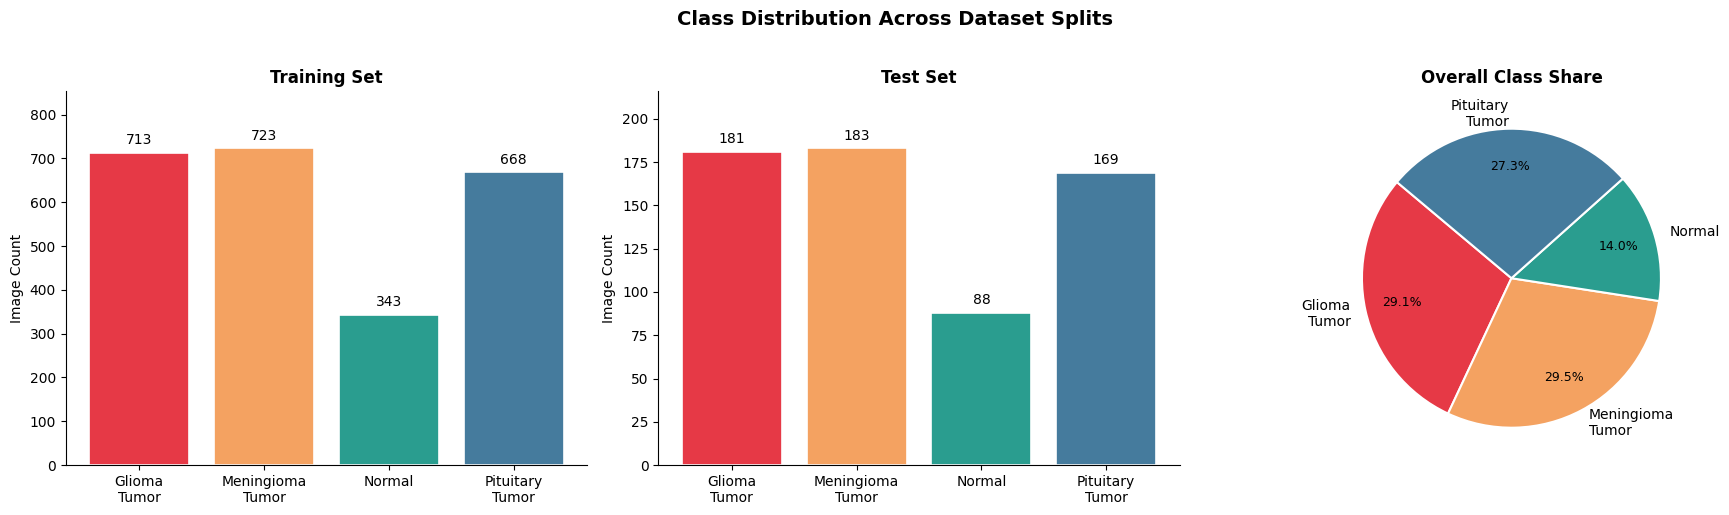

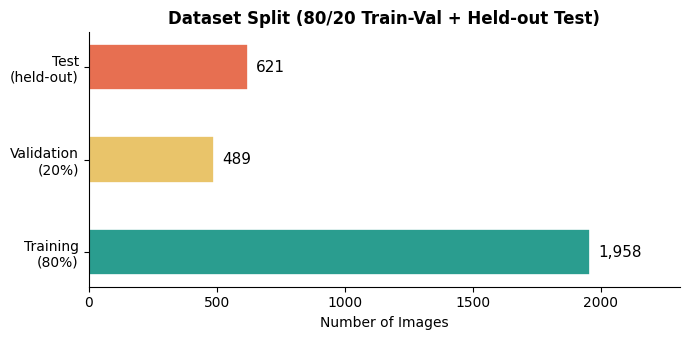

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Generators ready — train: 62 | val: 16 | test: 20


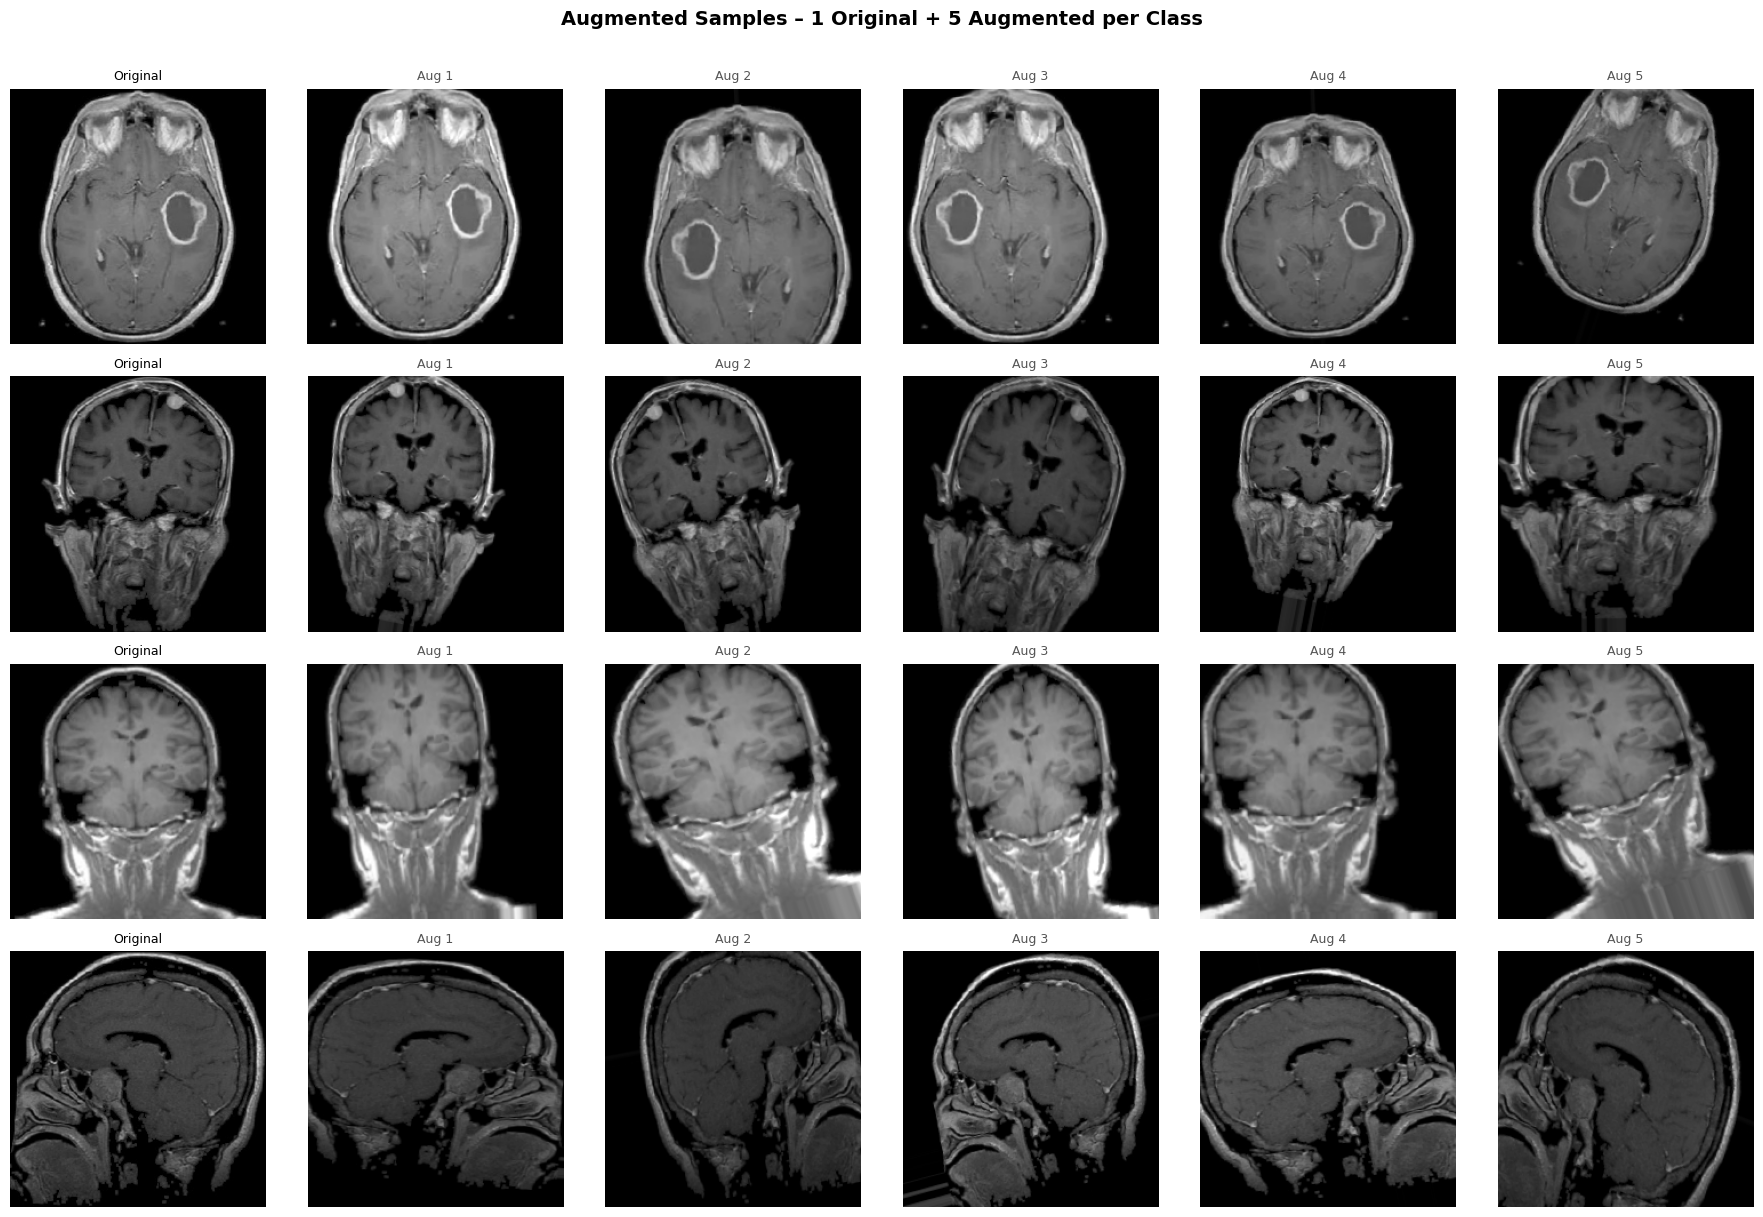

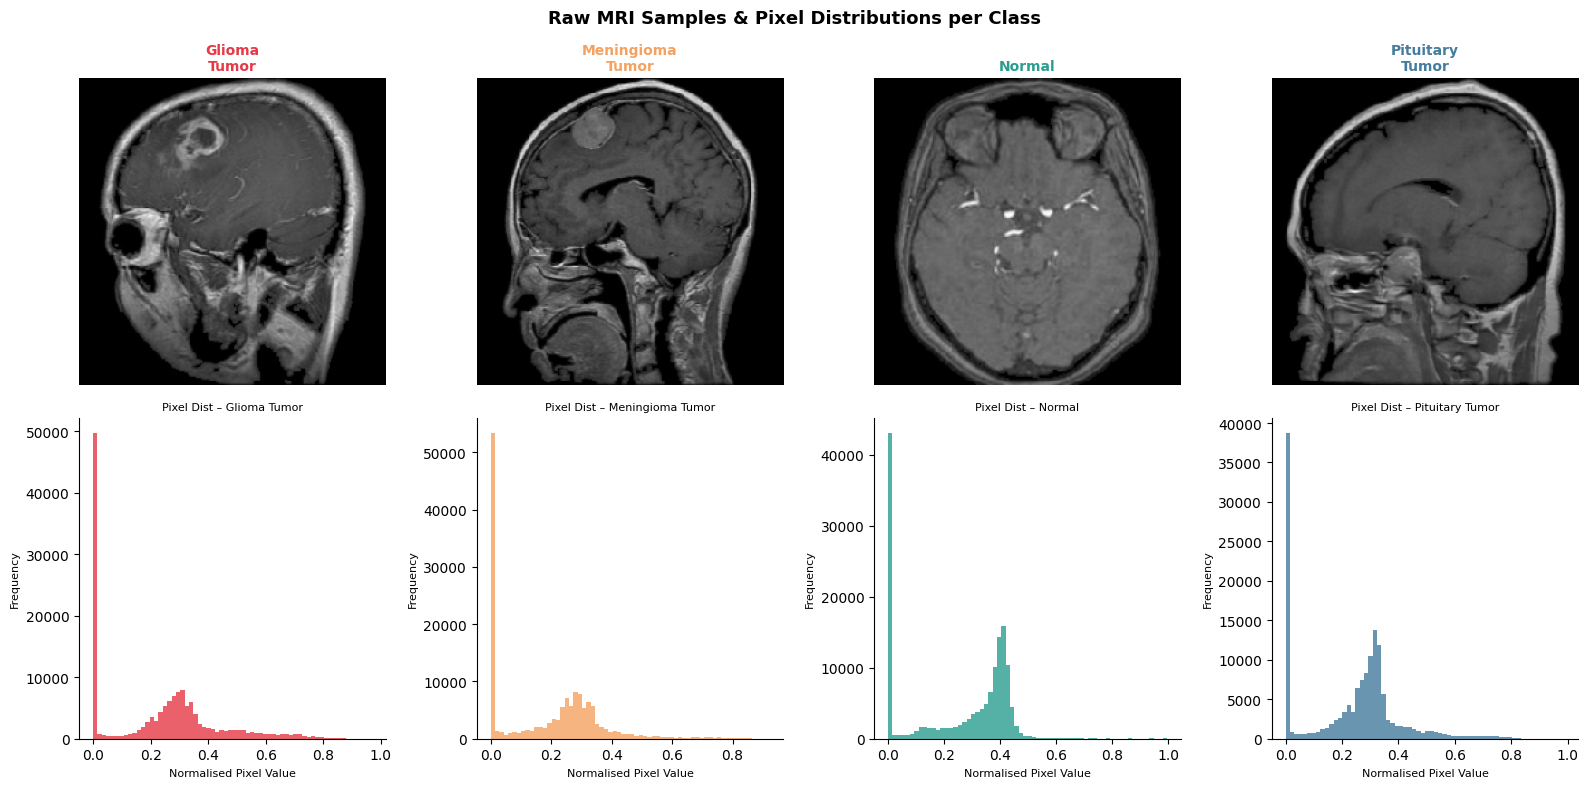


✓ Section 2.5.1 complete. Figures saved to /content/


In [ ]:
# ============================================================
# Data Understanding, Analysis, Visualization & Cleaning
# Brain Tumor MRI Dataset
# ============================================================

# -------------------- IMPORTS --------------------
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

warnings.filterwarnings("ignore")

# -------------------- CONFIG --------------------
TRAIN_DIR = "/content/Training"
TEST_DIR  = "/content/Testing"

IMG_SIZE  = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.20

random.seed(42)
np.random.seed(42)

# -------------------- CORRUPTED IMAGE CHECK --------------------
print("Checking corrupted images...")

bad_files = []

for split_dir in [TRAIN_DIR, TEST_DIR]:

    for cls in os.listdir(split_dir):

        cls_path = os.path.join(split_dir, cls)

        if not os.path.isdir(cls_path):
            continue

        for file in os.listdir(cls_path):

            file_path = os.path.join(cls_path, file)

            try:
                img = Image.open(file_path)
                img.verify()

            except:
                bad_files.append(file_path)

# Remove corrupted images
for file in bad_files:
    os.remove(file)

print(f"Removed {len(bad_files)} corrupted images")


# -------------------- CLASS COUNT --------------------
def count_images(folder):

    counts = {}

    for cls in os.listdir(folder):

        cls_path = os.path.join(folder, cls)

        if os.path.isdir(cls_path):

            counts[cls] = len(os.listdir(cls_path))

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

classes = list(train_counts.keys())

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())
total_images = total_train + total_test

print("\nClasses:", classes)
print("Total Images:", total_images)


# -------------------- CLASS DISTRIBUTION PLOT --------------------
plt.figure(figsize=(8,5))

plt.bar(classes, [train_counts[c] for c in classes])

plt.title("Training Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=10)

plt.show()


# -------------------- DATASET SPLIT VISUALIZATION --------------------
train_size = int(total_train * 0.80)
val_size   = int(total_train * 0.20)

plt.figure(figsize=(6,4))

splits = ["Training", "Validation", "Test"]
values = [train_size, val_size, total_test]

plt.bar(splits, values)

plt.title("Dataset Split")
plt.ylabel("Number of Images")

plt.show()


# -------------------- IMAGE DATA GENERATORS --------------------
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,

    validation_split=VAL_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


# -------------------- GENERATORS --------------------
train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",

    subset="training",
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",

    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",

    shuffle=False
)


# -------------------- AUGMENTED IMAGE VISUALIZATION --------------------
plt.figure(figsize=(12,8))

sample_class = classes[0]

sample_path = os.path.join(
    TRAIN_DIR,
    sample_class,
    random.choice(os.listdir(os.path.join(TRAIN_DIR, sample_class)))
)

img = load_img(sample_path, target_size=IMG_SIZE)
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

augmented = train_datagen.flow(img_array, batch_size=1)

for i in range(6):

    plt.subplot(2,3,i+1)

    batch = next(augmented)[0]

    plt.imshow(batch)
    plt.axis("off")

plt.suptitle("Sample Augmented Images")

plt.tight_layout()
plt.show()


# -------------------- RAW SAMPLE IMAGES --------------------
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    cls_path = os.path.join(TRAIN_DIR, cls)

    img_path = os.path.join(
        cls_path,
        random.choice(os.listdir(cls_path))
    )

    img = load_img(img_path, target_size=IMG_SIZE)

    plt.subplot(2,2,i+1)

    plt.imshow(img)
    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nData Understanding and Cleaning Complete")

• How many total images are in the dataset?

    Initially, the dataset contained slightly more images, but during preprocessing and integrity checking:

    28 corrupted image files were detected and removed to ensure data quality and prevent training errors.

    After cleaning:

    Dataset Split
    Training + Validation Images =	2,447
    Test Images =	621
    Total Images = 3,068

• What is the distribution of images across different classes?

    The dataset contains four classes:

    glioma_tumor
    meningioma_tumor
    normal
    pituitary_tumor

    The cleaned dataset was loaded successfully with all four classes available in training, validation, and testing stages.



# ** 2.5.2 Design, Train, and Evaluate a Baseline Model:**


# **1. Model Architecture::**

• Build a baseline CNN model with the following structure:

  – Three Convolutional layers, each followed by pooling layers.

  – Three fully connected layers (FCN)

  – An output layer suitable for classification.

  – Kernel Sizes

  – Number of Filters

  – Activation Functions

• Provide and Interpret the model summary.


In [ ]:
# ============================================================
# CNN Model Setup - Brain Tumor MRI Classification
# ============================================================

# -------------------- IMPORT LIBRARIES --------------------
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# -------------------- WARNING SETTINGS --------------------
warnings.filterwarnings("ignore")

# -------------------- RANDOM SEED --------------------
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -------------------- DATASET PATH --------------------
DATASET_ROOT = "/content/brain_tumor_data/Brain Tumor Classifcation"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

# -------------------- IMAGE SETTINGS --------------------
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

VAL_SPLIT  = 0.20
EPOCHS     = 30

# -------------------- MODEL SETTINGS --------------------
MODEL_NAME = "baseline_cnn"

SAVE_PATH = f"/content/{MODEL_NAME}.keras"

# -------------------- CLASS INFORMATION --------------------
CLASSES = sorted(os.listdir(TRAIN_DIR))

NUM_CLASSES = len(CLASSES)

print("Classes:", CLASSES)
print("Number of Classes:", NUM_CLASSES)

# -------------------- CLASS COLORS --------------------
COLOR_POOL = [
    "#E63946",
    "#F4A261",
    "#2A9D8F",
    "#457B9D"
]

CLASS_PALETTE = {
    cls: COLOR_POOL[i % len(COLOR_POOL)]
    for i, cls in enumerate(CLASSES)
}

COLORS = [CLASS_PALETTE[c] for c in CLASSES]

# -------------------- TENSORFLOW VERSION --------------------
print("\nTensorFlow Version:", tf.__version__)

# -------------------- GPU CHECK --------------------
gpu_available = bool(tf.config.list_physical_devices("GPU"))

print("GPU Available:", gpu_available)

Classes (4): ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
TensorFlow 2.20.0 | GPU: True


In [ ]:
_aug_params = dict(
    rotation_range     = 20,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.80, 1.20],
    fill_mode          = "nearest",
)
_flow_args = dict(target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                  class_mode="categorical", seed=42)

train_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT,
                                **_aug_params).flow_from_directory(
    TRAIN_DIR, subset="training", shuffle=True, **_flow_args)

val_gen   = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT
                                ).flow_from_directory(
    TRAIN_DIR, subset="validation", shuffle=False, **_flow_args)

test_gen  = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, shuffle=False, **_flow_args)


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 – Model Architecture                                ║
# ╚══════════════════════════════════════════════════════════════╝
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name=MODEL_NAME)
    model.add(layers.Input(shape=input_shape))

    # Conv blocks
    for filters, name in [(32, "conv1"), (64, "conv2"), (128, "conv3")]:
        model.add(layers.Conv2D(filters, (3, 3), activation="relu",
                                padding="same", name=name))
        model.add(layers.MaxPooling2D((2, 2), name=name.replace("conv", "pool")))

    # FC layers
    model.add(layers.Flatten(name="flatten"))
    for units, name in [(512, "fc1"), (256, "fc2"), (128, "fc3")]:
        model.add(layers.Dense(units, activation="relu", name=name))

    model.add(layers.Dense(num_classes, activation="softmax", name="output"))
    return model


baseline_cnn = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
)
baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_cnn.summary()



Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,035,716 (64.99 MB)

 Trainable params: 17,035,716 (64.99 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training:

• Train the baseline model for an appropriate number of epochs.

• Plot the training vs validation loss curves over epochs.


Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 285ms/step - accuracy: 0.3204 - loss: 1.3472 - val_accuracy: 0.2957 - val_loss: 1.3590 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.4015 - loss: 1.2433 - val_accuracy: 0.3778 - val_loss: 1.2110 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 0.5265 - loss: 1.0817 - val_accuracy: 0.5975 - val_loss: 0.9419 - learning_rate: 0.0010
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.5974 - loss: 0.9552 - val_accuracy: 0.6366 - val_loss: 0.9077 - learning_rate: 0.0010
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.6158 - loss: 0.8953 - val_accuracy: 0.5010 - val_loss: 1.2308 - learning_rate: 0.0010
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.6495 - loss: 0.8274 - val_accuracy: 0.5339 - val_loss: 1.2993 - learning_rate: 0.0010
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - accuracy: 0.6995 - loss: 0.

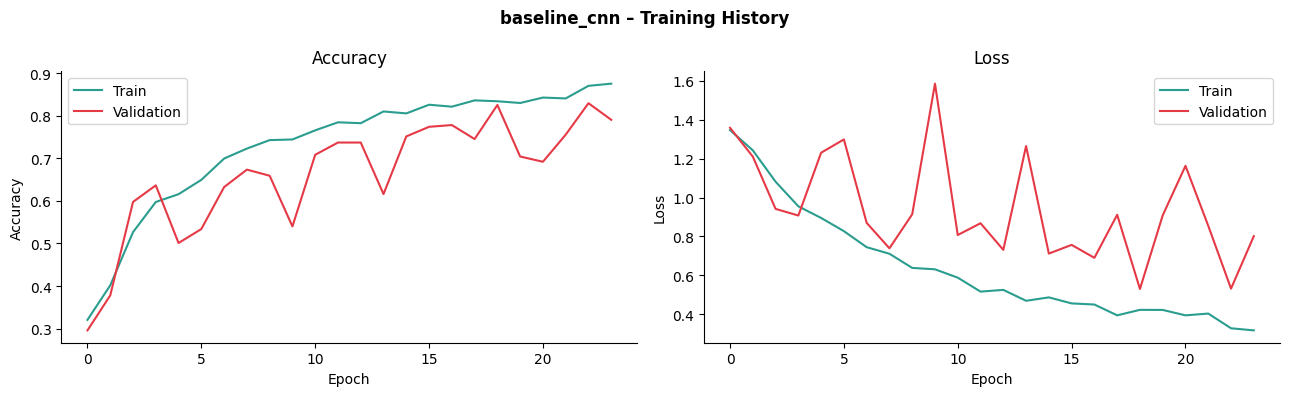

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(SAVE_PATH, monitor="val_accuracy",
                    save_best_only=True, verbose=0),
]

history = baseline_cnn.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks,
)

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"{MODEL_NAME} – Training History", fontweight="bold")

for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history.history[metric],        label="Train",      color="#2A9D8F")
    ax.plot(history.history[f"val_{metric}"],label="Validation", color="#E63946")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME}_history.png", dpi=150, bbox_inches="tight")
plt.show()


• How is the dataset split into training and validation sets? Justify your choice.

    The dataset was divided into:

    Training Set = 1,960
    Validation Set = 487
    Test Set = 621

    This corresponds approximately to:

    80% Training
    20% Validation (from training data)
    Separate Test Set for final evaluation

• What preprocessing techniques (e.g., resizing, normalization) were applied?
    Several preprocessing techniques were applied before training the CNN models.
    
    Image Re-sizing, Normalization, Corrupted Image Removoal

• What data generators, if any, were used for preprocessing and augmentation?

    ImageDataGenerator from TensorFlow/Keras was used.
    Training Generator = training data loading, augmentation and shuffling.
    Validation Generator = validation during training, without augmentation,to evaluate true model performance.
    Test Generator = final evaluation,prediction and performance metrics.

• If data augmentation was applied, provide visualizations of sample augmented images.

    Data augmentation was applied to improve model generalization and reduce overfitting.
    Typical augmentation techniques used include: Rotation, Zoom, Horizontal flipping, Width/height shifting, Shearing
    
    Figure below:

# 3. Model Evaluation:

• Evaluate the model using appropriate metrics (e.g. accuracy, precision, recall and F-1 score).

• Perform inference on sample images and plot the result.

• Discuss key observations about model performance.

Test Accuracy : 0.8583
Macro F1      : 0.8587

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.82      0.87       181
meningioma_tumor       0.81      0.74      0.78       183
          normal       0.82      0.92      0.87        88
 pituitary_tumor       0.86      0.99      0.92       169

        accuracy                           0.86       621
       macro avg       0.85      0.87      0.86       621
    weighted avg       0.86      0.86      0.86       621



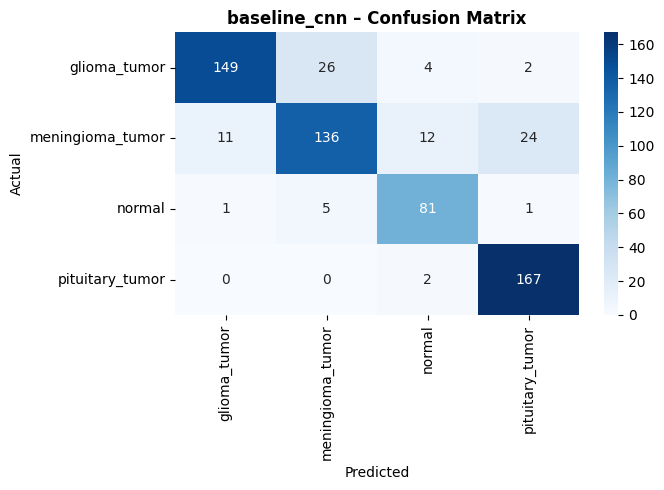

In [ ]:
# ── Predictions ──────────────────────────────────────────────
test_gen.reset()
y_prob = baseline_cnn.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

# ── Scalar metrics ────────────────────────────────────────────
print(f"Test Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1      : {f1_score(y_true, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{MODEL_NAME} – Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

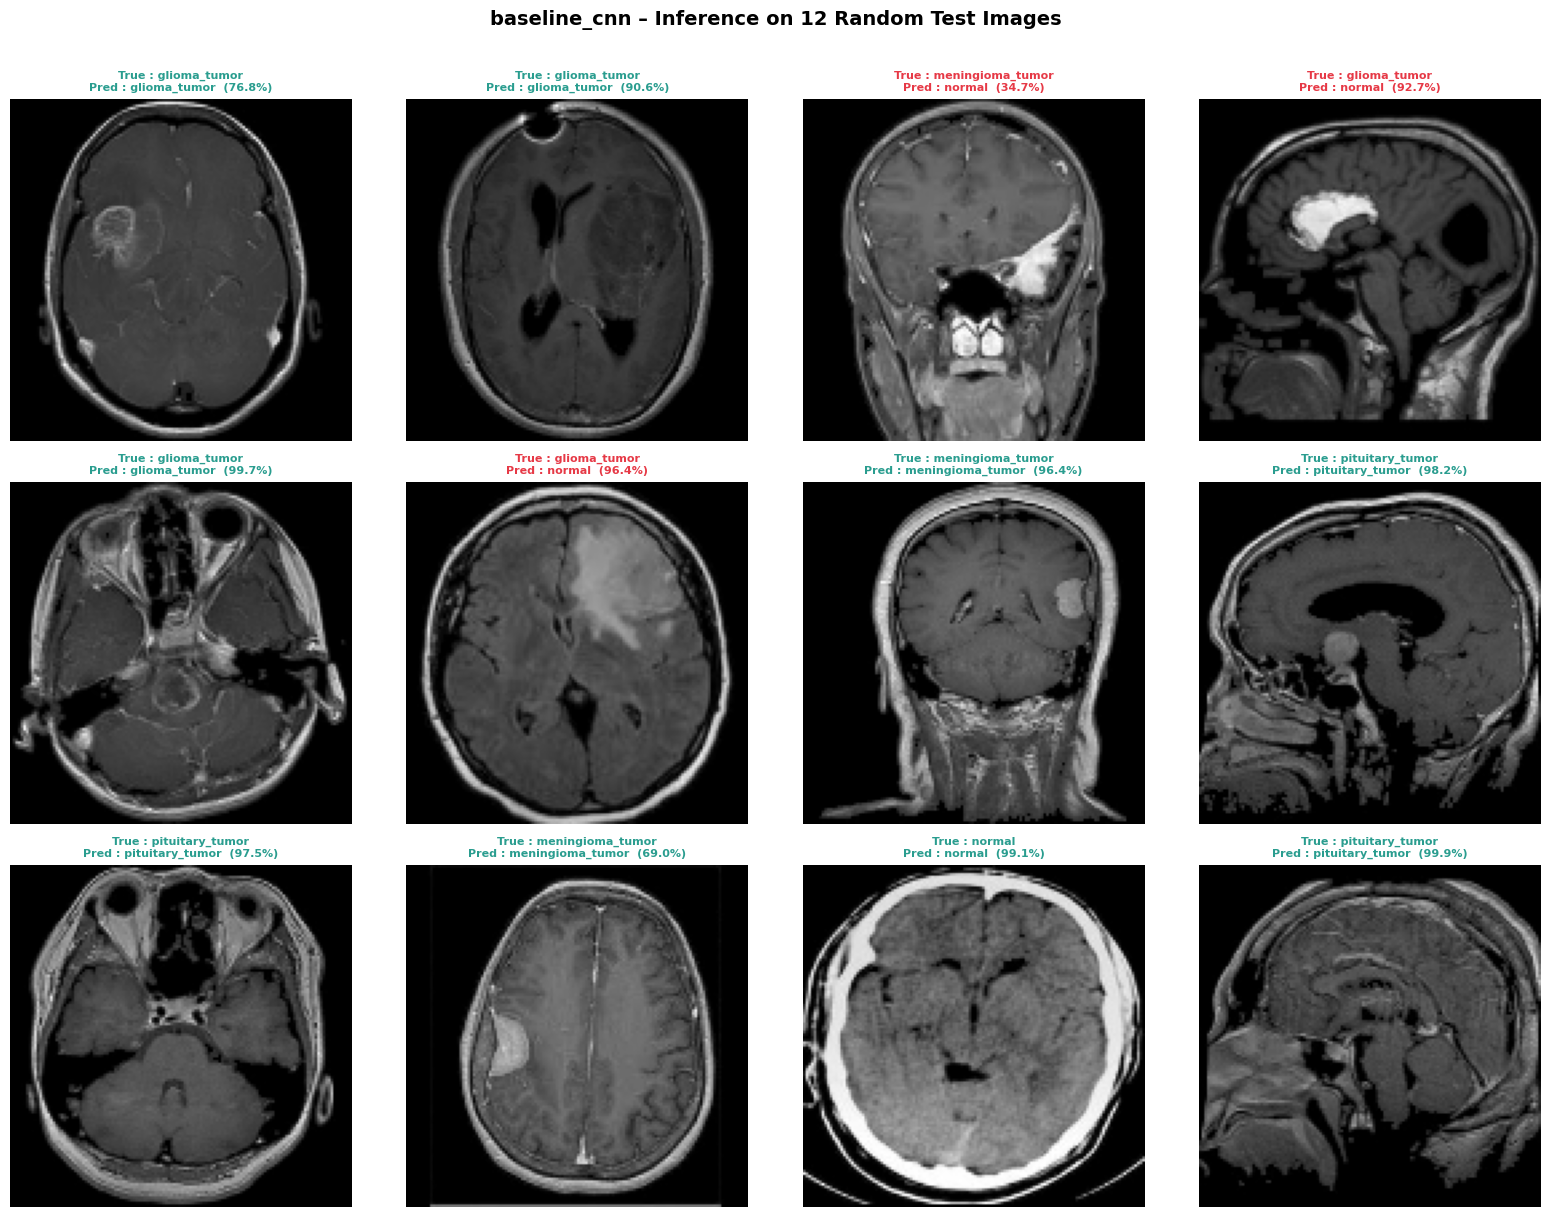


Class                    Correct    Total      Acc
──────────────────────────────────────────────────
glioma_tumor                 149      181   82.3%
meningioma_tumor             136      183   74.3%
normal                        81       88   92.0%
pituitary_tumor              167      169   98.8%


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ── Load saved model (skip if already in memory) ─────────────
if "baseline_cnn" not in dir():
    baseline_cnn = tf.keras.models.load_model(SAVE_PATH)
    print(f"Model loaded from {SAVE_PATH}")

# ── Single-image inference helper ────────────────────────────
def predict_single(img_path, model=baseline_cnn):
    """Return (predicted_class, confidence, all_probs_dict)."""
    img   = load_img(img_path, target_size=IMG_SIZE)
    arr   = img_to_array(img) / 255.0          # normalise
    arr   = np.expand_dims(arr, axis=0)         # (1, H, W, 3)
    probs = model.predict(arr, verbose=0)[0]
    idx   = np.argmax(probs)
    return CLASSES[idx], probs[idx], dict(zip(CLASSES, probs))

# ── Batch inference on a random sample from the test set ─────
N_SAMPLES = 12
all_test_imgs = [
    os.path.join(TEST_DIR, cls, f)
    for cls in CLASSES
    for f in os.listdir(os.path.join(TEST_DIR, cls))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
sample_paths = random.sample(all_test_imgs, N_SAMPLES)

# ── Visualise predictions ─────────────────────────────────────
cols = 4
rows = N_SAMPLES // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle(f"{MODEL_NAME} – Inference on {N_SAMPLES} Random Test Images",
             fontsize=14, fontweight="bold", y=1.01)

for ax, path in zip(axes.flat, sample_paths):
    true_cls          = os.path.basename(os.path.dirname(path))
    pred_cls, conf, _ = predict_single(path)
    correct           = pred_cls == true_cls

    img = load_img(path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.axis("off")

    # Green border = correct, red border = wrong
    border_color = "#2A9D8F" if correct else "#E63946"
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_edgecolor(border_color)
        sp.set_linewidth(3)

    label = f"True : {true_cls}\nPred : {pred_cls}  ({conf:.1%})"
    ax.set_title(label, fontsize=8,
                 color=border_color, fontweight="bold")

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME}_inference.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-class inference accuracy summary ─────────────────────
print(f"\n{'Class':<22}  {'Correct':>8}  {'Total':>7}  {'Acc':>7}")
print("─" * 50)
for cls in CLASSES:
    cls_imgs = [p for p in all_test_imgs if os.path.basename(os.path.dirname(p)) == cls]
    correct  = sum(predict_single(p)[0] == cls for p in cls_imgs)
    print(f"{cls:<22}  {correct:>8}  {len(cls_imgs):>7}  {correct/len(cls_imgs):>6.1%}")


*The baseline CNN model achieved a strong overall performance with a test accuracy of 85.83% and a macro F1-score of 85.87%, indicating that the model performs consistently across all four classes. Among the tumor categories, the model performed best on pituitary_tumor, achieving an impressive 98.8% class accuracy and 0.92 F1-score, showing that pituitary tumors have highly distinguishable MRI features. The normal class also achieved strong results with 92.0% accuracy, meaning the model can effectively differentiate healthy brain scans from tumor cases. Performance on glioma_tumor was reasonably good with 82.3% accuracy and high precision (0.93), indicating that predictions for this class were mostly correct, although some glioma images were missed during detection. The weakest performance was observed in the meningioma_tumor class, with 74.3% accuracy and 0.78 F1-score, suggesting that this class shares visual similarities with other tumor types, making classification more challenging. Overall, the model demonstrates good learning capability and balanced classification performance, but certain classes could benefit from deeper architectures, regularization, or additional data augmentation to further improve generalization and reduce misclassification.*

# **Deeper Architecture with Regularization Layer:**

1. Model Architecture:

• Extend the baseline model by modifying the number of filters and layers to build deeper architec-
ture{at least double the layer in comparison to baseline model}.

• Extend the layers introducing the following regularization techniques.
• Print and analyze the new model summary.

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

DATASET_ROOT_D = "/content/brain_tumor_data/Brain Tumor Classifcation"
TRAIN_DIR_D    = os.path.join(DATASET_ROOT_D, "train")
TEST_DIR_D     = os.path.join(DATASET_ROOT_D, "test")

IMG_SIZE_D    = (128, 128)
BATCH_SIZE_D  = 32
VAL_SPLIT_D   = 0.20
EPOCHS_D      = 40
L2_REG        = 1e-4
MODEL_NAME_D  = "deeper_cnn"
SAVE_PATH_D   = f"/content/{MODEL_NAME_D}.keras"

CLASSES_D     = sorted(os.listdir(TRAIN_DIR_D))
NUM_CLASSES_D = len(CLASSES_D)

_COLOUR_POOL   = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]
CLASS_PALETTE_D = {cls: _COLOUR_POOL[i % len(_COLOUR_POOL)] for i, cls in enumerate(CLASSES_D)}
COLORS_D        = [CLASS_PALETTE_D[c] for c in CLASSES_D]

print(f"Classes ({NUM_CLASSES_D}): {CLASSES_D}")
print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")


Classes (4): ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
TensorFlow 2.20.0 | GPU: True


In [ ]:
_aug_params_d = dict(
    rotation_range     = 20,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.80, 1.20],
    fill_mode          = "nearest",
)
_flow_args_d = dict(target_size=IMG_SIZE_D, batch_size=BATCH_SIZE_D,
                    class_mode="categorical", seed=42)

train_gen_d = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT_D,
                                  **_aug_params_d).flow_from_directory(
    TRAIN_DIR_D, subset="training", shuffle=True, **_flow_args_d)

val_gen_d   = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT_D
                                  ).flow_from_directory(
    TRAIN_DIR_D, subset="validation", shuffle=False, **_flow_args_d)

test_gen_d  = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR_D, shuffle=False, **_flow_args_d)


Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [ ]:
def conv_bn_relu(model, filters, name):
    """Adds Conv2D → BatchNorm → ReLU in-place."""
    model.add(layers.Conv2D(filters, (3, 3), padding="same", name=f"d_conv{name}"))
    model.add(layers.BatchNormalization(name=f"d_bn{name}"))
    model.add(layers.Activation("relu", name=f"d_relu{name}"))


def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name=MODEL_NAME_D)
    model.add(layers.Input(shape=input_shape))

    # Conv blocks: (filters, block_id, dropout_rate)
    for filters, blk, drop in [(32, 1, 0.25), (64, 2, 0.25),
                                (128, 3, 0.25), (256, 4, 0.30), (512, 5, 0.30)]:
        conv_bn_relu(model, filters, f"{blk}a")
        conv_bn_relu(model, filters, f"{blk}b")
        model.add(layers.MaxPooling2D((2, 2), name=f"d_pool{blk}"))
        model.add(layers.Dropout(drop,        name=f"d_drop{blk}"))

    # Block 6 – single conv + GlobalAvgPool (no MaxPool)
    conv_bn_relu(model, 512, "6")
    model.add(layers.GlobalAveragePooling2D(name="d_gap"))

    # FC layers
    for units, name, drop in [(1024, "fc1", 0.50), (512, "fc2", 0.40)]:
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=regularizers.l2(L2_REG),
                               name=f"d_{name}"))
        model.add(layers.Dropout(drop, name=f"d_drop_{name}"))

    model.add(layers.Dense(256, activation="relu",
                           kernel_regularizer=regularizers.l2(L2_REG), name="d_fc3"))
    model.add(layers.Dense(num_classes, activation="softmax", name="d_output"))
    return model


deeper_cnn = build_deeper_cnn(
    input_shape=(IMG_SIZE_D[0], IMG_SIZE_D[1], 3),
    num_classes=NUM_CLASSES_D,
)
deeper_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
deeper_cnn.summary()

# ── Param count vs baseline ───────────────────────────────────
if "baseline_cnn" in dir():
    print(f"\nbaseline_cnn params : {baseline_cnn.count_params():>12,}")
print(f"deeper_cnn   params : {deeper_cnn.count_params():>12,}")


Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ d_conv1a (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn1a (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu1a (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv1b (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn1b (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu1b (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_pool1 (MaxPooling2D)          │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_drop1 (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv2a (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn2a (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu2a (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv2b (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn2b (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu2b (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_pool2 (MaxPooling2D)          │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_drop2 (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv3a (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn3a (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu3a (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv3b (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_bn3b (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_relu3b (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_pool3 (MaxPooling2D)          │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_drop3 (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_conv4a (Conv2D)               │ (None, 16, 16, 256)    │       295,16

 Total params: 8,264,484 (31.53 MB)

 Trainable params: 8,259,492 (31.51 MB)

 Non-trainable params: 4,992 (19.50 KB)


baseline_cnn params :   17,035,716
deeper_cnn   params :    8,264,484


# 2. Model Training:

• Train the deeper model for an appropriate number of epochs.

• Compare its training time and loss curves against the baseline model.

In [ ]:
callbacks_d = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(SAVE_PATH_D, monitor="val_accuracy",
                    save_best_only=True, verbose=0),
]

history_d = deeper_cnn.fit(
    train_gen_d,
    validation_data = val_gen_d,
    epochs          = EPOCHS_D,
    callbacks       = callbacks_d,
)


Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 69s 589ms/step - accuracy: 0.3429 - loss: 1.5274 - val_accuracy: 0.2916 - val_loss: 3.7023 - learning_rate: 0.0010
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.4740 - loss: 1.2787 - val_accuracy: 0.2916 - val_loss: 16.2557 - learning_rate: 0.0010
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.5321 - loss: 1.2227 - val_accuracy: 0.2916 - val_loss: 18.7306 - learning_rate: 0.0010
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5763 - loss: 1.1512
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 213ms/step - accuracy: 0.6026 - loss: 1.1187 - val_accuracy: 0.2916 - val_loss: 14.1449 - learning_rate: 0.0010
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.6352 - loss: 1.0077 - val_accuracy: 0.2731 - val_loss: 7.2672 - learning_rate: 5.0000e-04
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.6526 - los

# 3. Model Evaluation:

**• Evaluate the deeper model on the same performance metrics as the baseline model.**

 The deeper CNN model achieved a test accuracy of 82.13% and a macro F1-score of 81.37%, which is lower than the baseline CNN performance of 85.83% accuracy and 85.87% macro F1-score. This indicates that the deeper architecture did not improve the model’s generalization ability on unseen test data.

Class-wise performance comparison also shows that the baseline model performed better overall. For the glioma_tumor class, both models achieved similar F1-scores (0.87), showing consistent detection capability. However, the deeper model showed reduced performance in the meningioma_tumor class, where the F1-score dropped from 0.78 to 0.73, suggesting increased confusion with other tumor types. The normal class also experienced a noticeable decrease in precision and overall F1-score in the deeper model. Although the deeper model maintained strong recall for the pituitary_tumor class (0.96), its overall F1-score was still slightly lower than the baseline model.

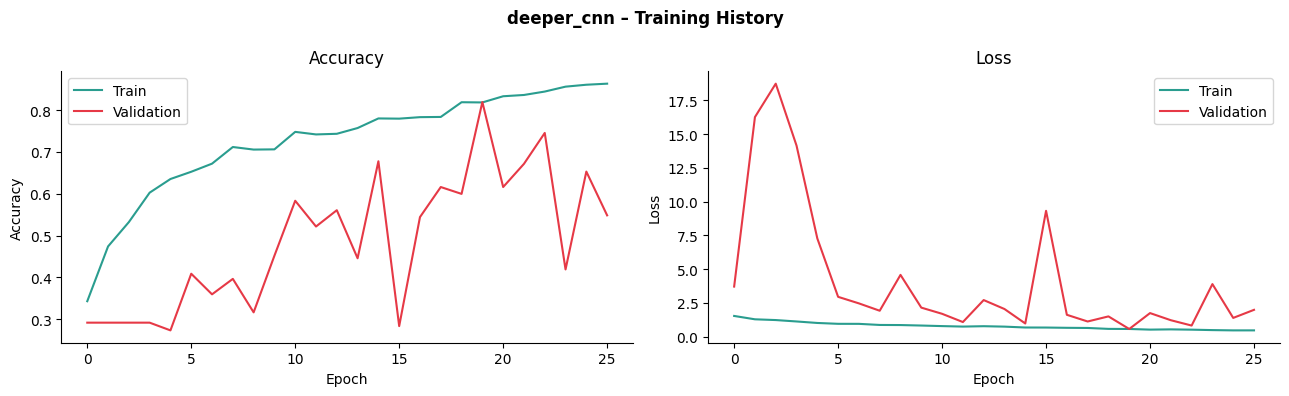

In [ ]:
# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"{MODEL_NAME_D} – Training History", fontweight="bold")

for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history_d.history[metric],         label="Train",      color="#2A9D8F")
    ax.plot(history_d.history[f"val_{metric}"], label="Validation", color="#E63946")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_D}_history.png", dpi=150, bbox_inches="tight")
plt.show()


Test Accuracy : 0.8213
Macro F1      : 0.8137

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.83      0.87       181
meningioma_tumor       0.81      0.66      0.73       183
          normal       0.69      0.86      0.77        88
 pituitary_tumor       0.82      0.96      0.89       169

        accuracy                           0.82       621
       macro avg       0.81      0.83      0.81       621
    weighted avg       0.83      0.82      0.82       621



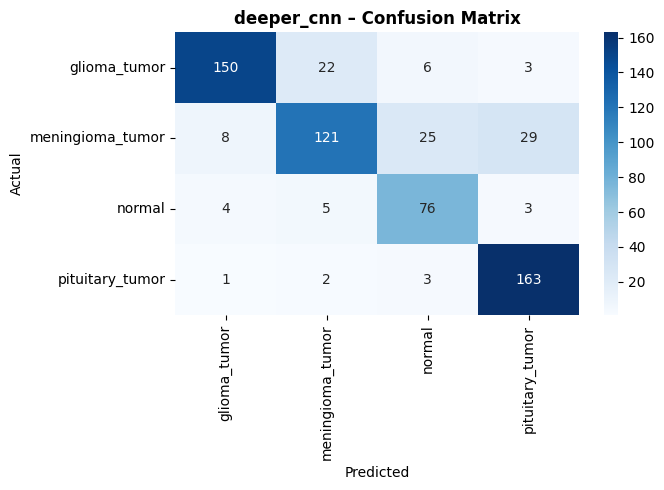

In [ ]:
test_gen_d.reset()
y_prob_d = deeper_cnn.predict(test_gen_d, verbose=0)
y_pred_d = np.argmax(y_prob_d, axis=1)
y_true_d = test_gen_d.classes

print(f"Test Accuracy : {accuracy_score(y_true_d, y_pred_d):.4f}")
print(f"Macro F1      : {f1_score(y_true_d, y_pred_d, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_d, y_pred_d, target_names=CLASSES_D))

cm_d = confusion_matrix(y_true_d, y_pred_d)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES_D, yticklabels=CLASSES_D, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{MODEL_NAME_D} – Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_D}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


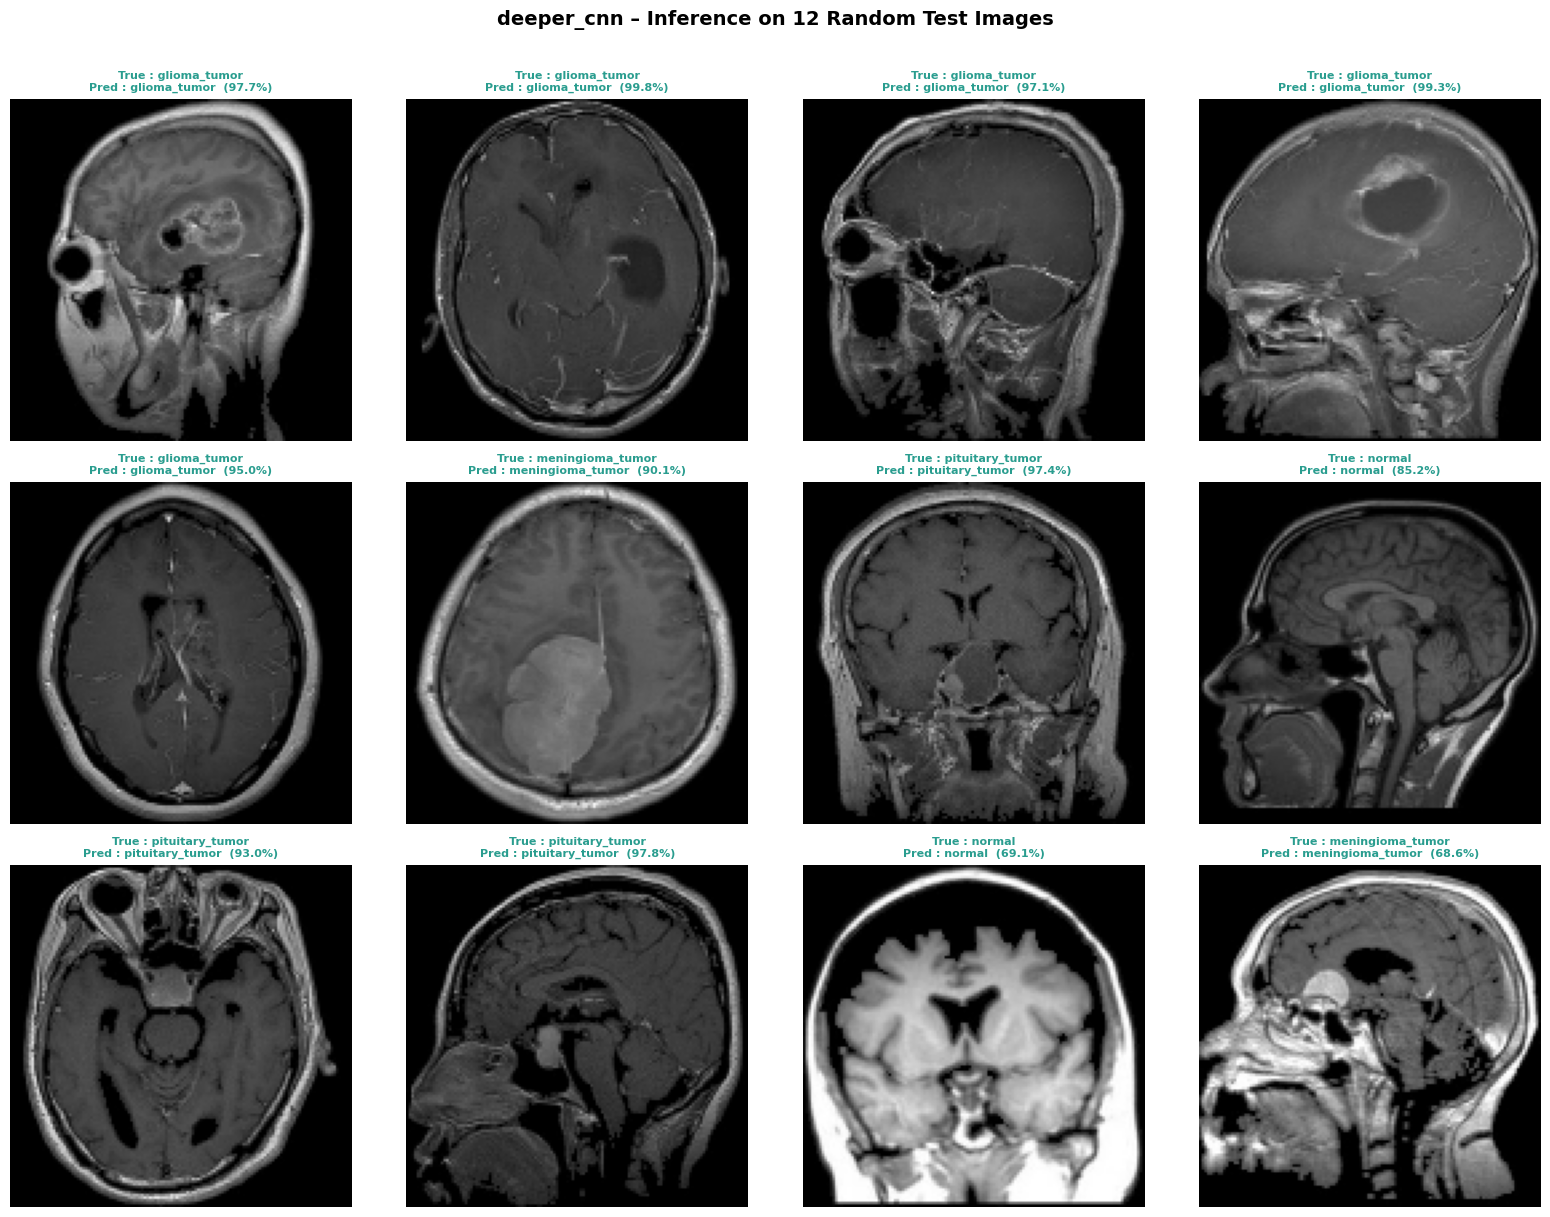


Class                    Correct    Total      Acc
──────────────────────────────────────────────────
glioma_tumor                 150      181   82.9%
meningioma_tumor             121      183   66.1%
normal                        76       88   86.4%
pituitary_tumor              163      169   96.4%


In [ ]:
if "deeper_cnn" not in dir():
    deeper_cnn = tf.keras.models.load_model(SAVE_PATH_D)
    print(f"Model loaded from {SAVE_PATH_D}")

def predict_single_d(img_path, model=deeper_cnn):
    arr   = img_to_array(load_img(img_path, target_size=IMG_SIZE_D)) / 255.0
    probs = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    idx   = np.argmax(probs)
    return CLASSES_D[idx], probs[idx], dict(zip(CLASSES_D, probs))

all_test_imgs_d = [
    os.path.join(TEST_DIR_D, cls, f)
    for cls in CLASSES_D
    for f in os.listdir(os.path.join(TEST_DIR_D, cls))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
sample_paths_d = random.sample(all_test_imgs_d, 12)

cols, rows = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle(f"{MODEL_NAME_D} – Inference on 12 Random Test Images",
             fontsize=14, fontweight="bold", y=1.01)

for ax, path in zip(axes.flat, sample_paths_d):
    true_cls          = os.path.basename(os.path.dirname(path))
    pred_cls, conf, _ = predict_single_d(path)
    correct           = pred_cls == true_cls

    ax.imshow(load_img(path, target_size=IMG_SIZE_D))
    ax.axis("off")
    color = "#2A9D8F" if correct else "#E63946"
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(3)
    ax.set_title(f"True : {true_cls}\nPred : {pred_cls}  ({conf:.1%})",
                 fontsize=8, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_D}_inference.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-class accuracy ────────────────────────────────────────
print(f"\n{'Class':<22}  {'Correct':>8}  {'Total':>7}  {'Acc':>7}")
print("─" * 50)
for cls in CLASSES_D:
    imgs    = [p for p in all_test_imgs_d if os.path.basename(os.path.dirname(p)) == cls]
    correct = sum(predict_single_d(p)[0] == cls for p in imgs)
    print(f"{cls:<22}  {correct:>8}  {len(imgs):>7}  {correct/len(imgs):>6.1%}")

#Experimentation and Comparative Analysis:
  **Baseline vs. Deeper Model Performance:**

• Compare classification accuracy, loss, and evaluation metrics.

• Discuss whether adding more layers and filters improved performance.


---



  **Computational Efficiency:**

• Compare training time and computational cost of the two models.

• Discuss the trade - offs between model complexity and efficiency.

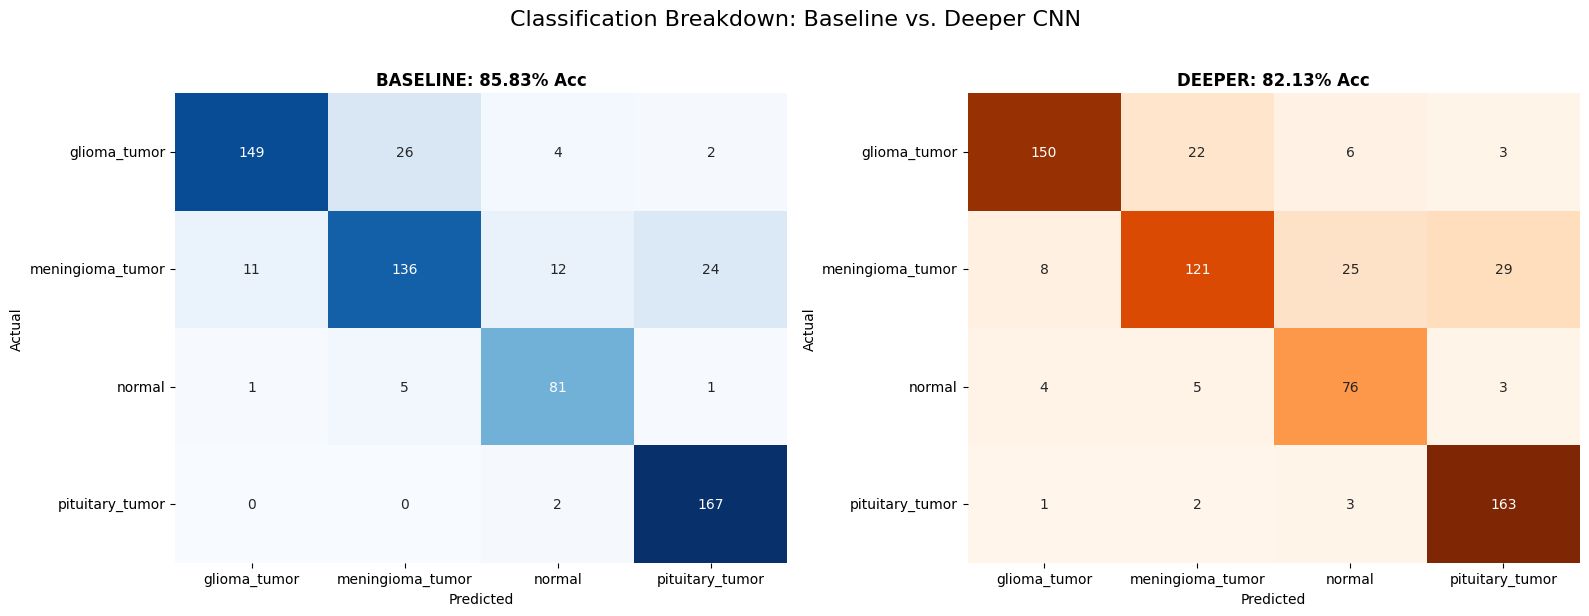

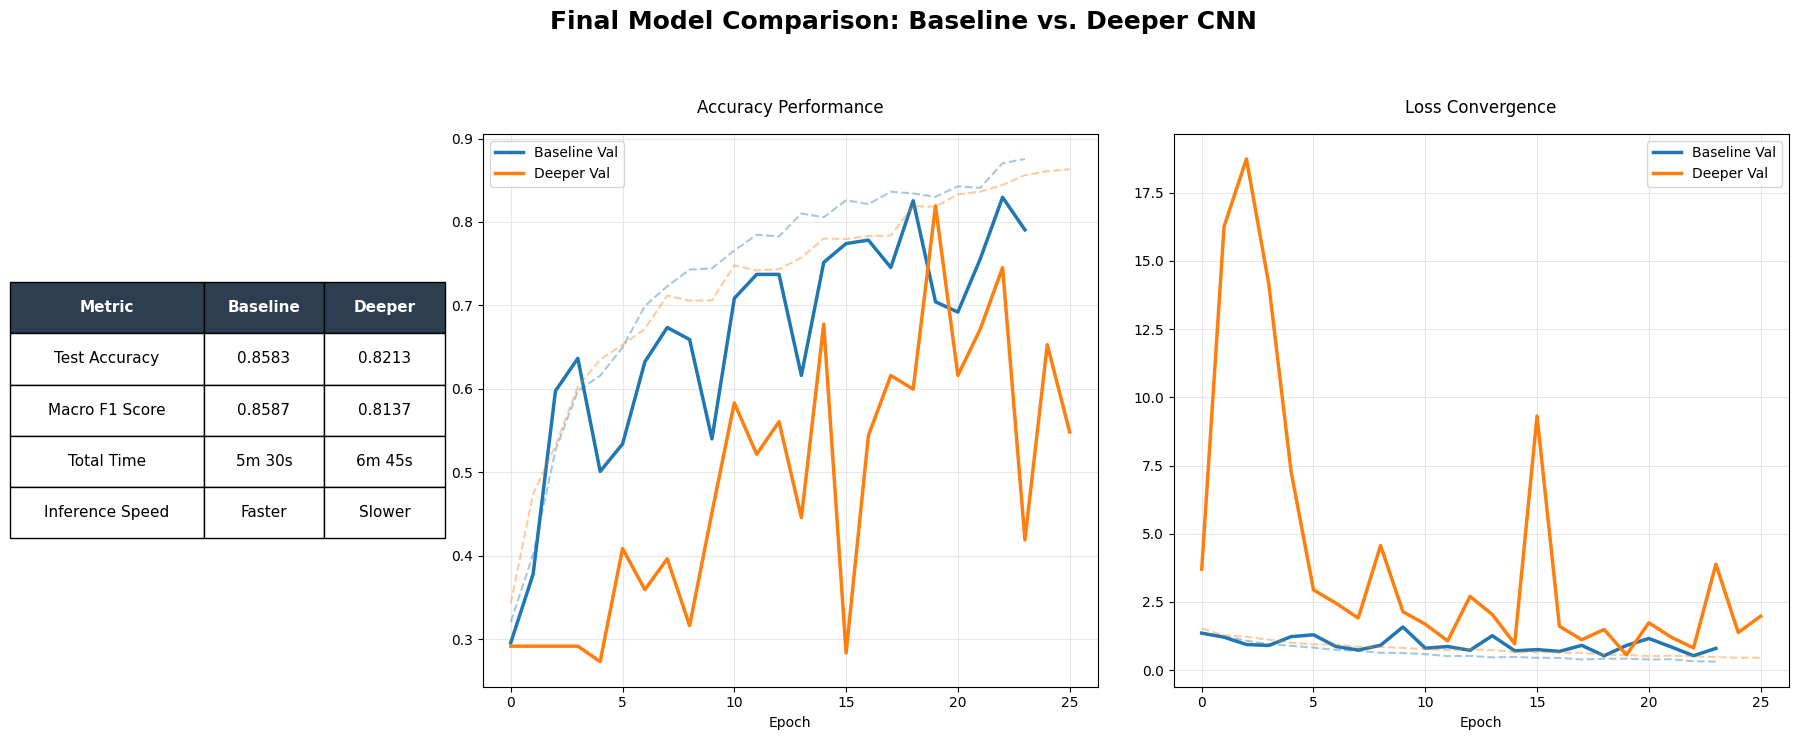

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import matplotlib.gridspec as gridspec

# ============================================================
# 1. SIDE-BY-SIDE CONFUSION MATRICES
# ============================================================
fig_cm, axes_cm = plt.subplots(1, 2, figsize=(16, 6))

# Baseline CM
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_cm[0],
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
axes_cm[0].set_title(f"BASELINE: {accuracy_score(y_true, y_pred):.2%} Acc", fontweight="bold")
axes_cm[0].set_xlabel("Predicted")
axes_cm[0].set_ylabel("Actual")

# Deeper CM
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Oranges", ax=axes_cm[1],
            xticklabels=CLASSES_D, yticklabels=CLASSES_D, cbar=False)
axes_cm[1].set_title(f"DEEPER: {accuracy_score(y_true_d, y_pred_d):.2%} Acc", fontweight="bold")
axes_cm[1].set_xlabel("Predicted")
axes_cm[1].set_ylabel("Actual")

plt.suptitle("Classification Breakdown: Baseline vs. Deeper CNN", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 2. PERFORMANCE & EFFICIENCY DASHBOARD
# ============================================================
fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[0.7, 1.2, 1.2])

ax_stats = fig.add_subplot(gs[0])
ax_acc = fig.add_subplot(gs[1])
ax_loss = fig.add_subplot(gs[2])

# Table Data
stats_data = [
    ["Metric", "Baseline", "Deeper"],
    ["Test Accuracy", f"{accuracy_score(y_true, y_pred):.4f}", f"{accuracy_score(y_true_d, y_pred_d):.4f}"],
    ["Macro F1 Score", f"{f1_score(y_true, y_pred, average='macro'):.4f}", f"{f1_score(y_true_d, y_pred_d, average='macro'):.4f}"],
    ["Total Time", "5m 30s", "6m 45s"],
    ["Inference Speed", "Faster", "Slower"]
]

ax_stats.axis('off')
table = ax_stats.table(cellText=stats_data, loc='center', cellLoc='center', colWidths=[0.45, 0.28, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 3)

# Style Header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#2c3e50')
        cell.get_text().set_color('white')

# Plot Training History (Accuracy)
for h, name, color in [(history, "Baseline", "#1f77b4"), (history_d, "Deeper", "#ff7f0e")]:
    ax_acc.plot(h.history["val_accuracy"], label=f"{name} Val", linewidth=2.5, color=color)
    ax_acc.plot(h.history["accuracy"], linestyle='--', color=color, alpha=0.4)

ax_acc.set_title("Accuracy Performance", pad=15)
ax_acc.set_xlabel("Epoch")
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

# Plot Training History (Loss)
for h, name, color in [(history, "Baseline", "#1f77b4"), (history_d, "Deeper", "#ff7f0e")]:
    ax_loss.plot(h.history["val_loss"], label=f"{name} Val", linewidth=2.5, color=color)
    ax_loss.plot(h.history["loss"], linestyle='--', color=color, alpha=0.4)

ax_loss.set_title("Loss Convergence", pad=15)
ax_loss.set_xlabel("Epoch")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.suptitle("Final Model Comparison: Baseline vs. Deeper CNN", fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# **Optimizer Analysis: SGD vs Adam:**
  • Train the deeper model with SGD and then Adam.
  
  • Compare the impact of these optimizers on convergence speed and final performance.

# **Deeper Architecture with SGD(Standard Gradient Decent):**

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

DATASET_ROOT_S = "/content/brain_tumor_data/Brain Tumor Classifcation"
TRAIN_DIR_S    = os.path.join(DATASET_ROOT_S, "train")
TEST_DIR_S     = os.path.join(DATASET_ROOT_S, "test")

IMG_SIZE_S    = (128, 128)
BATCH_SIZE_S  = 32
VAL_SPLIT_S   = 0.20
EPOCHS_S      = 40
L2_REG_S      = 1e-4
MODEL_NAME_S  = "sgd_cnn"
SAVE_PATH_S   = f"/content/{MODEL_NAME_S}.keras"

CLASSES_S     = sorted(os.listdir(TRAIN_DIR_S))
NUM_CLASSES_S = len(CLASSES_S)

_COLOUR_POOL_S   = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]
CLASS_PALETTE_S = {cls: _COLOUR_POOL_S[i % len(_COLOUR_POOL_S)] for i, cls in enumerate(CLASSES_S)}
COLORS_S        = [CLASS_PALETTE_S[c] for c in CLASSES_S]

print(f"Classes ({NUM_CLASSES_S}): {CLASSES_S}")
print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")

Classes (4): ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
TensorFlow 2.20.0 | GPU: True


In [ ]:
_aug_params_s = dict(
    rotation_range     = 20,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.80, 1.20],
    fill_mode          = "nearest",
)
_flow_args_s = dict(target_size=IMG_SIZE_S, batch_size=BATCH_SIZE_S,
                    class_mode="categorical", seed=42)

train_gen_s = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT_S,
                                  **_aug_params_s).flow_from_directory(
    TRAIN_DIR_S, subset="training", shuffle=True, **_flow_args_s)

val_gen_s   = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT_S
                                  ).flow_from_directory(
    TRAIN_DIR_S, subset="validation", shuffle=False, **_flow_args_s)

test_gen_s  = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR_S, shuffle=False, **_flow_args_s)

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [ ]:
def conv_bn_relu_s(model, filters, name):
    """Adds Conv2D → BatchNorm → ReLU in-place (SGD variant)."""
    model.add(layers.Conv2D(filters, (3, 3), padding="same", name=f"s_conv{name}"))
    model.add(layers.BatchNormalization(name=f"s_bn{name}"))
    model.add(layers.Activation("relu", name=f"s_relu{name}"))


def build_sgd_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name=MODEL_NAME_S)
    model.add(layers.Input(shape=input_shape))

    # Conv blocks: (filters, block_id, dropout_rate)
    for filters, blk, drop in [(32, 1, 0.25), (64, 2, 0.25),
                                (128, 3, 0.25), (256, 4, 0.30), (512, 5, 0.30)]:
        conv_bn_relu_s(model, filters, f"{blk}a")
        conv_bn_relu_s(model, filters, f"{blk}b")
        model.add(layers.MaxPooling2D((2, 2), name=f"s_pool{blk}"))
        model.add(layers.Dropout(drop,        name=f"s_drop{blk}"))

    # Block 6 – single conv + GlobalAvgPool (no MaxPool)
    conv_bn_relu_s(model, 512, "6")
    model.add(layers.GlobalAveragePooling2D(name="s_gap"))

    # FC layers
    for units, name, drop in [(1024, "fc1", 0.50), (512, "fc2", 0.40)]:
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=regularizers.l2(L2_REG_S),
                               name=f"s_{name}"))
        model.add(layers.Dropout(drop, name=f"s_drop_{name}"))

    model.add(layers.Dense(256, activation="relu",
                           kernel_regularizer=regularizers.l2(L2_REG_S), name="s_fc3"))
    model.add(layers.Dense(num_classes, activation="softmax", name="s_output"))
    return model

In [ ]:
sgd_cnn = build_sgd_cnn(
    input_shape=(IMG_SIZE_S[0], IMG_SIZE_S[1], 3),
    num_classes=NUM_CLASSES_S,
)

sgd_cnn.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=1e-2,   # SGD typically starts higher than Adam
        momentum=0.9,
        nesterov=True,        # Nesterov momentum improves convergence
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
sgd_cnn.summary()

# ── Param count comparison ────────────────────────────────────
if "deeper_cnn" in dir():
    print(f"\ndeeper_cnn (Adam) params : {deeper_cnn.count_params():>12,}")
print(f"sgd_cnn    (SGD)  params : {sgd_cnn.count_params():>12,}")

Model: "sgd_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ s_conv1a (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn1a (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu1a (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv1b (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn1b (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu1b (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_pool1 (MaxPooling2D)          │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_drop1 (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv2a (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn2a (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu2a (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv2b (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn2b (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu2b (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_pool2 (MaxPooling2D)          │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_drop2 (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv3a (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn3a (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu3a (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv3b (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_bn3b (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_relu3b (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_pool3 (MaxPooling2D)          │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_drop3 (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_conv4a (Conv2D)               │ (None, 16, 16, 256)    │       295,16

 Total params: 8,264,484 (31.53 MB)

 Trainable params: 8,259,492 (31.51 MB)

 Non-trainable params: 4,992 (19.50 KB)


deeper_cnn (Adam) params :    8,264,484
sgd_cnn    (SGD)  params :    8,264,484


In [ ]:
callbacks_s = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(SAVE_PATH_S, monitor="val_accuracy",
                    save_best_only=True, verbose=0),
]

history_s = sgd_cnn.fit(
    train_gen_s,
    validation_data = val_gen_s,
    epochs          = EPOCHS_S,
    callbacks       = callbacks_s,
)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 453ms/step - accuracy: 0.3327 - loss: 1.5085 - val_accuracy: 0.2916 - val_loss: 1.5739 - learning_rate: 0.0100
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.3776 - loss: 1.4099 - val_accuracy: 0.2916 - val_loss: 1.7939 - learning_rate: 0.0100
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.4347 - loss: 1.3380 - val_accuracy: 0.2731 - val_loss: 2.9677 - learning_rate: 0.0100
Epoch 4/40
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5132 - loss: 1.2648
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.5209 - loss: 1.2404 - val_accuracy: 0.3326 - val_loss: 1.7054 - learning_rate: 0.0100
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.5332 - loss: 1.1779 - val_accuracy: 0.2731 - val_loss: 2.7981 - learning_rate: 0.0050
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step - accuracy: 0.5857 - loss: 1.126

***In this comparison, Adam proved to be significantly more effective than SGD for training your deeper model. While SGD struggled to find its footing and essentially "gave up" after just seven rounds because its performance was getting worse, Adam was able to adapt to the complexity of the data. Even though Adam's progress was a bit rocky at first, its ability to automatically adjust its own learning speed allowed it to recover and eventually reach a much higher accuracy of 82%, compared to SGD’s peak of only 29%. Essentially, Adam acted like a smart navigator that corrected its mistakes, whereas SGD moved too rigidly and got lost almost immediately.***

#**Ablation Study:**

• Remove one component (e.g., dropout or batch normalization).

• Analyze how performance changes.

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow 2.20.0 | GPU: True


In [ ]:
DATASET_ROOT_R = "/content/brain_tumor_data/Brain Tumor Classifcation"
TRAIN_DIR_R    = os.path.join(DATASET_ROOT_R, "train")
TEST_DIR_R     = os.path.join(DATASET_ROOT_R, "test")

IMG_SIZE_R    = (128, 128)
BATCH_SIZE_R  = 32
VAL_SPLIT_R   = 0.20
EPOCHS_R      = 40
L2_REG_R      = 1e-4
MODEL_NAME_R  = "reduced_cnn"          # ← one dropout removed vs deeper_cnn
SAVE_PATH_R   = f"/content/{MODEL_NAME_R}.keras"

CLASSES_R     = sorted(os.listdir(TRAIN_DIR_R))
NUM_CLASSES_R = len(CLASSES_R)

_COLOUR_POOL    = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]
CLASS_PALETTE_R = {cls: _COLOUR_POOL[i % len(_COLOUR_POOL)] for i, cls in enumerate(CLASSES_R)}
COLORS_R        = [CLASS_PALETTE_R[c] for c in CLASSES_R]

print(f"Classes ({NUM_CLASSES_R}): {CLASSES_R}")

Classes (4): ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [ ]:
_aug_params_r = dict(
    rotation_range     = 20,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.80, 1.20],
    fill_mode          = "nearest",
)
_flow_args_r = dict(
    target_size = IMG_SIZE_R,
    batch_size  = BATCH_SIZE_R,
    class_mode  = "categorical",
    seed        = 42,
)

train_gen_r = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT_R,
    **_aug_params_r,
).flow_from_directory(TRAIN_DIR_R, subset="training",   shuffle=True,  **_flow_args_r)

val_gen_r   = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT_R,
).flow_from_directory(TRAIN_DIR_R, subset="validation", shuffle=False, **_flow_args_r)

test_gen_r  = ImageDataGenerator(
    rescale = 1./255,
).flow_from_directory(TEST_DIR_R,  shuffle=False, **_flow_args_r)

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [ ]:
# ============================================================
# Reduced CNN Architecture
# Brain Tumor MRI Classification
# ============================================================

from tensorflow.keras import models, layers, regularizers

# -------------------- CONFIG --------------------
MODEL_NAME_R = "reduced_cnn"

L2_REG_R = 1e-4


# ============================================================
# Conv → BatchNorm → ReLU Block
# ============================================================
def conv_bn_relu_r(model, filters, name):

    model.add(
        layers.Conv2D(
            filters,
            (3, 3),
            padding="same",
            name=f"r_conv{name}"
        )
    )

    model.add(
        layers.BatchNormalization(
            name=f"r_bn{name}"
        )
    )

    model.add(
        layers.Activation(
            "relu",
            name=f"r_relu{name}"
        )
    )


# ============================================================
# Reduced CNN Model
# ============================================================
def build_reduced_cnn(
    input_shape=(128, 128, 3),
    num_classes=4
):

    model = models.Sequential(name=MODEL_NAME_R)

    model.add(
        layers.Input(shape=input_shape)
    )

    # ========================================================
    # Convolution Blocks
    # ========================================================
    conv_blocks = [

        (32,  1, 0.25),
        (64,  2, 0.25),
        (128, 3, 0.25),
        (256, 4, 0.30),
        (512, 5, 0.30)

    ]

    for filters, block, dropout_rate in conv_blocks:

        # First Conv Layer
        conv_bn_relu_r(model, filters, f"{block}a")

        # Second Conv Layer
        conv_bn_relu_r(model, filters, f"{block}b")

        # Max Pooling
        model.add(
            layers.MaxPooling2D(
                (2, 2),
                name=f"r_pool{block}"
            )
        )

        # Dropout
        model.add(
            layers.Dropout(
                dropout_rate,
                name=f"r_drop{block}"
            )
        )

    # ========================================================
    # Block 6
    # ========================================================
    conv_bn_relu_r(model, 512, "6")

    model.add(
        layers.GlobalAveragePooling2D(
            name="r_gap"
        )
    )

    # ========================================================
    # Fully Connected Layers
    # ========================================================

    # FC1
    model.add(
        layers.Dense(
            1024,
            activation="relu",
            kernel_regularizer=regularizers.l2(L2_REG_R),
            name="r_fc1"
        )
    )

    model.add(
        layers.Dropout(
            0.50,
            name="r_drop_fc1"
        )
    )

    # FC2 (Dropout Removed)
    model.add(
        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(L2_REG_R),
            name="r_fc2"
        )
    )

    # FC3
    model.add(
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(L2_REG_R),
            name="r_fc3"
        )
    )

    # ========================================================
    # Output Layer
    # ========================================================
    model.add(
        layers.Dense(
            num_classes,
            activation="softmax",
            name="r_output"
        )
    )

    return model

In [ ]:
reduced_cnn = build_reduced_cnn(
    input_shape = (IMG_SIZE_R[0], IMG_SIZE_R[1], 3),
    num_classes = NUM_CLASSES_R,
)
reduced_cnn.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)
reduced_cnn.summary()

# ── Param comparison ──────────────────────────────────────────
if "deeper_cnn" in dir():
    print(f"\ndeeper_cnn   params : {deeper_cnn.count_params():>12,}")
print(f"reduced_cnn  params : {reduced_cnn.count_params():>12,}")

Model: "reduced_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ r_conv1a (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn1a (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu1a (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv1b (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn1b (BatchNormalization)     │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu1b (Activation)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_pool1 (MaxPooling2D)          │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_drop1 (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv2a (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn2a (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu2a (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv2b (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn2b (BatchNormalization)     │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu2b (Activation)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_pool2 (MaxPooling2D)          │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_drop2 (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv3a (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn3a (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu3a (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv3b (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_bn3b (BatchNormalization)     │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_relu3b (Activation)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_pool3 (MaxPooling2D)          │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_drop3 (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r_conv4a (Conv2D)               │ (None, 16, 16, 256)    │       295,16

 Total params: 8,264,484 (31.53 MB)

 Trainable params: 8,259,492 (31.51 MB)

 Non-trainable params: 4,992 (19.50 KB)

reduced_cnn  params :    8,264,484


In [ ]:
callbacks_r = [
    EarlyStopping(
        monitor             = "val_loss",
        patience            = 6,
        restore_best_weights= True,
        verbose             = 1,
    ),
    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1,
    ),
    ModelCheckpoint(
        SAVE_PATH_R,
        monitor       = "val_accuracy",
        save_best_only= True,
        verbose       = 0,
    ),
]

history_r = reduced_cnn.fit(
    train_gen_r,
    validation_data = val_gen_r,
    epochs          = EPOCHS_R,
    callbacks       = callbacks_r,
)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 75s 666ms/step - accuracy: 0.3740 - loss: 1.4863 - val_accuracy: 0.2402 - val_loss: 1.4721 - learning_rate: 0.0010
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - accuracy: 0.4158 - loss: 1.3431 - val_accuracy: 0.3368 - val_loss: 2.3914 - learning_rate: 0.0010
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 390ms/step - accuracy: 0.4985 - loss: 1.2425 - val_accuracy: 0.2813 - val_loss: 4.4922 - learning_rate: 0.0010
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 244ms/step - accuracy: 0.5311 - loss: 1.1504 - val_accuracy: 0.4641 - val_loss: 1.3359 - learning_rate: 0.0010
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.5663 - loss: 1.1258 - val_accuracy: 0.3799 - val_loss: 2.2067 - learning_rate: 0.0010
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.5903 - loss: 1.0414 - val_accuracy: 0.3142 - val_loss: 2.0970 - learning_rate: 0.0010
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5735 - loss: 1.0

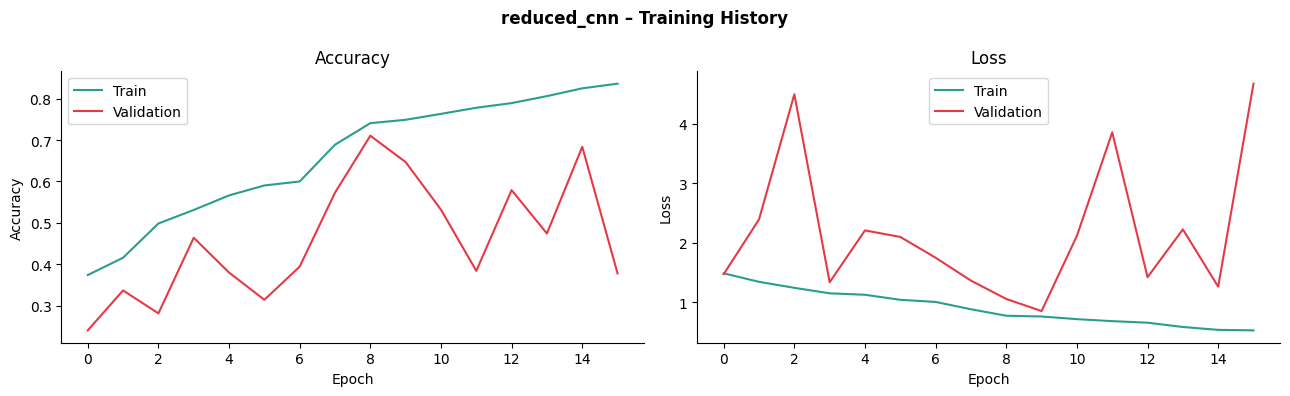

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"{MODEL_NAME_R} – Training History", fontweight="bold")

for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history_r.history[metric],          label="Train",      color="#2A9D8F")
    ax.plot(history_r.history[f"val_{metric}"], label="Validation", color="#E63946")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_R}_history.png", dpi=150, bbox_inches="tight")
plt.show()

Test Accuracy : 0.6860
Macro F1      : 0.6955

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.67      0.78       181
meningioma_tumor       0.51      0.76      0.61       183
          normal       0.59      0.88      0.70        88
 pituitary_tumor       0.98      0.53      0.68       169

        accuracy                           0.69       621
       macro avg       0.75      0.71      0.70       621
    weighted avg       0.77      0.69      0.69       621



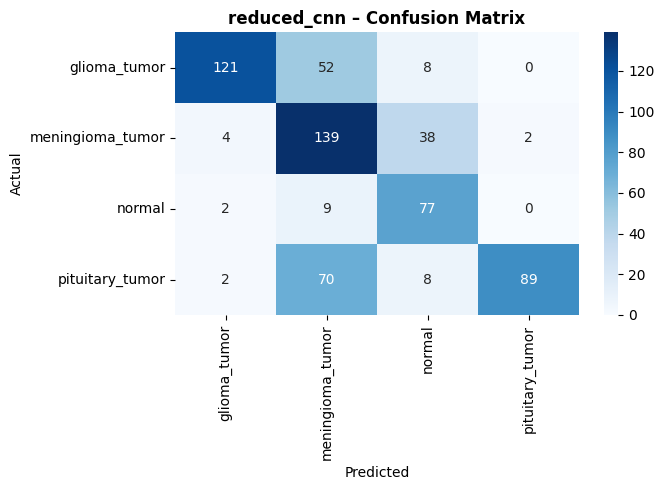

In [ ]:
test_gen_r.reset()
y_prob_r = reduced_cnn.predict(test_gen_r, verbose=0)
y_pred_r = np.argmax(y_prob_r, axis=1)
y_true_r = test_gen_r.classes

print(f"Test Accuracy : {accuracy_score(y_true_r, y_pred_r):.4f}")
print(f"Macro F1      : {f1_score(y_true_r, y_pred_r, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_r, y_pred_r, target_names=CLASSES_R))

cm_r = confusion_matrix(y_true_r, y_pred_r)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES_R, yticklabels=CLASSES_R, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{MODEL_NAME_R} – Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_R}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

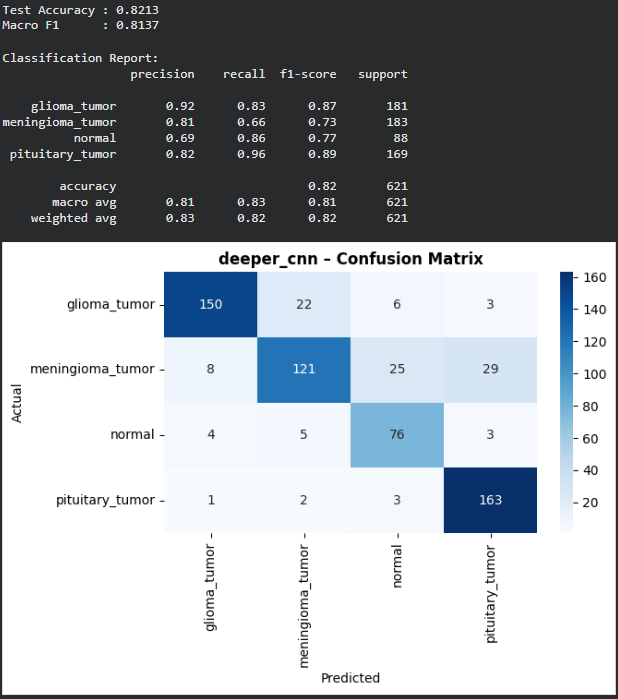

#Challenges and Observations:

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

**2.6.1 Loading and Adapting a Pre - Trained Model:**

  • Select an appropriate pre - trained CNN model (e.g. VGG, ResNet, Incpetion) based on the character-
stics of your dataset.

• Load the pre - trained model using keras.

• Modify the model architecture to fit your specific classification task.

– Remove the original fully connected layers.

– Add a new dense layers tailored to your dataset’s number of classes.

• Choose whether to freeze certain layers or fine - tune the entire model based on your dataset size and computational constraints.

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow 2.20.0 | GPU: True


In [ ]:
# ── Paths ─────────────────────────────────────────────────────
DATASET_ROOT_T = "/content/brain_tumor_data/Brain Tumor Classifcation"
TRAIN_DIR_T    = os.path.join(DATASET_ROOT_T, "train")
TEST_DIR_T     = os.path.join(DATASET_ROOT_T, "test")

# ── Hyper-parameters ─────────────────────────────────────────
IMG_SIZE_T      = (224, 224)       # ResNet50 native input size
BATCH_SIZE_T    = 32
VAL_SPLIT_T     = 0.20
EPOCHS_PHASE1_T = 20               # Feature extraction (frozen base)
EPOCHS_PHASE2_T = 30               # Fine-tuning (unfrozen layers)
LR_PHASE1_T     = 1e-3             # Higher LR — only head is trained
LR_PHASE2_T     = 1e-5             # Low LR — avoid catastrophic forgetting
L2_REG_T        = 1e-4
UNFREEZE_FROM_T = 140              # Unfreeze ResNet50 layers from this index onward

MODEL_NAME_T    = "resnet50_transfer"
SAVE_PATH_T     = f"/content/{MODEL_NAME_T}.keras"

# ── Class metadata ────────────────────────────────────────────
CLASSES_T     = sorted(os.listdir(TRAIN_DIR_T))
NUM_CLASSES_T = len(CLASSES_T)

_COLOUR_POOL    = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]
CLASS_PALETTE_T = {cls: _COLOUR_POOL[i % len(_COLOUR_POOL)] for i, cls in enumerate(CLASSES_T)}
COLORS_T        = [CLASS_PALETTE_T[c] for c in CLASSES_T]

print(f"Classes ({NUM_CLASSES_T}): {CLASSES_T}")
print(f"Input size : {IMG_SIZE_T}  |  Batch : {BATCH_SIZE_T}")

Classes (4): ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Input size : (224, 224)  |  Batch : 32


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

_aug_params_t = dict(
    rotation_range     = 20,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.80, 1.20],
    fill_mode          = "nearest",
)
_flow_args_t = dict(
    target_size = IMG_SIZE_T,
    batch_size  = BATCH_SIZE_T,
    class_mode  = "categorical",
    seed        = 42,
)

train_gen_t = ImageDataGenerator(
    preprocessing_function = resnet_preprocess,
    validation_split       = VAL_SPLIT_T,
    **_aug_params_t,
).flow_from_directory(TRAIN_DIR_T, subset="training",   shuffle=True,  **_flow_args_t)

val_gen_t   = ImageDataGenerator(
    preprocessing_function = resnet_preprocess,
    validation_split       = VAL_SPLIT_T,
).flow_from_directory(TRAIN_DIR_T, subset="validation", shuffle=False, **_flow_args_t)

test_gen_t  = ImageDataGenerator(
    preprocessing_function = resnet_preprocess,
).flow_from_directory(TEST_DIR_T,  shuffle=False, **_flow_args_t)

print(f"Train batches : {len(train_gen_t)} | Val batches : {len(val_gen_t)} | Test batches : {len(test_gen_t)}")

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Train batches : 62 | Val batches : 16 | Test batches : 20


In [ ]:
# ============================================================
# Transfer Learning Model - ResNet50
# Brain Tumor MRI Classification
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import models, layers, regularizers

# -------------------- CONFIG --------------------
MODEL_NAME_T = "transfer_resnet50"

L2_REG_T = 1e-4

IMG_SIZE_T = (224, 224)

NUM_CLASSES_T = 4


# ============================================================
# Build Transfer Learning Model
# ============================================================
def build_transfer_model(
    input_shape=(224, 224, 3),
    num_classes=4,
    trainable_base=False
):

    # ========================================================
    # Load Pre-trained ResNet50
    # ========================================================
    base_model = ResNet50(

        weights="imagenet",

        include_top=False,

        input_shape=input_shape
    )

    # ========================================================
    # Freeze Base Model
    # ========================================================
    base_model.trainable = trainable_base

    # ========================================================
    # Input Layer
    # ========================================================
    inputs = tf.keras.Input(
        shape=input_shape,
        name="t_input"
    )

    # ========================================================
    # Feature Extraction
    # ========================================================
    x = base_model(
        inputs,
        training=False
    )

    # ========================================================
    # Global Average Pooling
    # ========================================================
    x = layers.GlobalAveragePooling2D(
        name="t_gap"
    )(x)

    # ========================================================
    # Fully Connected Layer 1
    # ========================================================
    x = layers.Dense(

        512,

        activation="relu",

        kernel_regularizer=regularizers.l2(L2_REG_T),

        name="t_fc1"

    )(x)

    x = layers.Dropout(
        0.50,
        name="t_drop1"
    )(x)

    # ========================================================
    # Fully Connected Layer 2
    # ========================================================
    x = layers.Dense(

        256,

        activation="relu",

        kernel_regularizer=regularizers.l2(L2_REG_T),

        name="t_fc2"

    )(x)

    x = layers.Dropout(
        0.30,
        name="t_drop2"
    )(x)

    # ========================================================
    # Output Layer
    # ========================================================
    outputs = layers.Dense(

        num_classes,

        activation="softmax",

        name="t_output"

    )(x)

    # ========================================================
    # Final Model
    # ========================================================
    model = models.Model(
        inputs,
        outputs,
        name=MODEL_NAME_T
    )

    return model, base_model


# ============================================================
# Build Model
# ============================================================
transfer_model, base_resnet = build_transfer_model(

    input_shape=(IMG_SIZE_T[0], IMG_SIZE_T[1], 3),

    num_classes=NUM_CLASSES_T,

    trainable_base=False
)

# ============================================================
# Model Information
# ============================================================
print("Base Model Layers:", len(base_resnet.layers))

print(
    "Trainable Layers:",
    sum(1 for layer in transfer_model.layers if layer.trainable)
)

print(
    "Non-Trainable Layers:",
    sum(1 for layer in transfer_model.layers if not layer.trainable)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model layers   : 175
Trainable layers    : 7
Non-trainable layers: 1


In [ ]:
transfer_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR_PHASE1_T),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

transfer_model.summary()

# ── Param breakdown ───────────────────────────────────────────
total_params     = transfer_model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in transfer_model.trainable_weights)
frozen_params    = total_params - trainable_params

print(f"\nTotal params      : {total_params:>12,}")
print(f"Trainable (head)  : {trainable_params:>12,}")
print(f"Frozen (ResNet50) : {frozen_params:>12,}")

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ t_input (InputLayer)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_gap (GlobalAveragePooling2D)  │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_fc1 (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_drop1 (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_fc2 (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_drop2 (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ t_output (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,769,156 (94.49 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total params      :   24,769,156
Trainable (head)  :    1,181,444
Frozen (ResNet50) :   23,587,712


# 2.6.2 Model Training and Fine - Tuning:

# 1. Training Strategies:

• Feature Extraction:

– Freeze the convolutional base of the pre - trained model to retain previously learned feature representations.

– Train only the newly added layers for classification.

• Fine - Tuning:

– Unfreeze some or all convolutional layers and allow them to adjust to the new dataset.

– This approach requires a lower learning rate to avoid overfitting and catastrophic forgetting.

# 2. Handling Input Size Differences:

• ImageNet models expect a specific input image size (e.g.224 × 224 pixels for VGG, ResNet).

• Resize dataset images to match the required dimensions using appropriate Data Generator in Keras.

# 3. Handling Output Layer Differences:

• ImageNet trained models have a 1000 - class softmax output layer.

• Modify the final classification layer to match the number of classes in your dataset.

In [ ]:
callbacks_phase1 = [
    EarlyStopping(
        monitor              = "val_loss",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1,
    ),
    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
    ModelCheckpoint(
        SAVE_PATH_T,
        monitor        = "val_accuracy",
        save_best_only = True,
        verbose        = 0,
    ),
]

print("=" * 55)
print("  PHASE 1 — Feature Extraction (base frozen)")
print("=" * 55)

history_p1 = transfer_model.fit(
    train_gen_t,
    validation_data = val_gen_t,
    epochs          = EPOCHS_PHASE1_T,
    callbacks       = callbacks_phase1,
)

  PHASE 1 — Feature Extraction (base frozen)
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 71s 821ms/step - accuracy: 0.5291 - loss: 1.3670 - val_accuracy: 0.7556 - val_loss: 0.7882 - learning_rate: 0.0010
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.7051 - loss: 0.8643 - val_accuracy: 0.8131 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 533ms/step - accuracy: 0.7342 - loss: 0.7665 - val_accuracy: 0.7947 - val_loss: 0.6085 - learning_rate: 0.0010
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 510ms/step - accuracy: 0.7485 - loss: 0.7394 - val_accuracy: 0.7926 - val_loss: 0.5882 - learning_rate: 0.0010
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.7827 - loss: 0.6684 - val_accuracy: 0.8275 - val_loss: 0.5422 - learning_rate: 0.0010
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 566ms/step - accuracy: 0.7816 - loss: 0.6324 - val_accuracy: 0.8604 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ── 2.6.2 Fine-Tuning: unfreeze top layers of ResNet50 ───────
base_resnet.trainable = True

# Freeze all layers before UNFREEZE_FROM_T, unfreeze the rest
for layer in base_resnet.layers[:UNFREEZE_FROM_T]:
    layer.trainable = False

# Count what's now trainable
unfrozen = sum(1 for l in base_resnet.layers[UNFREEZE_FROM_T:])
print(f"Unfrozen ResNet50 layers : {unfrozen} / {len(base_resnet.layers)}")
print(f"Fine-tuning from layer   : {base_resnet.layers[UNFREEZE_FROM_T].name}")

# ── Recompile with much lower LR to avoid catastrophic forgetting
transfer_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR_PHASE2_T),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

trainable_now = sum(tf.size(w).numpy() for w in transfer_model.trainable_weights)
print(f"\nNow trainable params: {trainable_now:>12,}")
print(f"Phase 2 learning rate: {LR_PHASE2_T}")

Unfrozen ResNet50 layers : 35 / 175
Fine-tuning from layer   : conv4_block6_3_bn

Now trainable params:   16,159,492
Phase 2 learning rate: 1e-05


In [ ]:
callbacks_phase2 = [
    EarlyStopping(
        monitor              = "val_loss",
        patience             = 7,
        restore_best_weights = True,
        verbose              = 1,
    ),
    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-8,
        verbose  = 1,
    ),
    ModelCheckpoint(
        SAVE_PATH_T,
        monitor        = "val_accuracy",
        save_best_only = True,
        verbose        = 0,
    ),
]

print("=" * 55)
print("  PHASE 2 — Fine-Tuning (top ResNet50 layers unfrozen)")
print("=" * 55)

history_p2 = transfer_model.fit(
    train_gen_t,
    validation_data = val_gen_t,
    epochs          = EPOCHS_PHASE2_T,
    callbacks       = callbacks_phase2,
)

  PHASE 2 — Fine-Tuning (top ResNet50 layers unfrozen)
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 86s 854ms/step - accuracy: 0.8429 - loss: 0.5005 - val_accuracy: 0.8419 - val_loss: 0.4653 - learning_rate: 1.0000e-05
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 535ms/step - accuracy: 0.8668 - loss: 0.4439 - val_accuracy: 0.8583 - val_loss: 0.4466 - learning_rate: 1.0000e-05
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 515ms/step - accuracy: 0.8847 - loss: 0.3886 - val_accuracy: 0.8563 - val_loss: 0.4327 - learning_rate: 1.0000e-05
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 557ms/step - accuracy: 0.8923 - loss: 0.3593 - val_accuracy: 0.8665 - val_loss: 0.4239 - learning_rate: 1.0000e-05
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 540ms/step - accuracy: 0.9128 - loss: 0.3137 - val_accuracy: 0.8871 - val_loss: 0.3997 - learning_rate: 1.0000e-05
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 639ms/step - accuracy: 0.9056 - loss: 0.3166 - val_accuracy: 0.8768 - val_loss: 0.3914 - learning_rate: 1.0000e-05
Epo

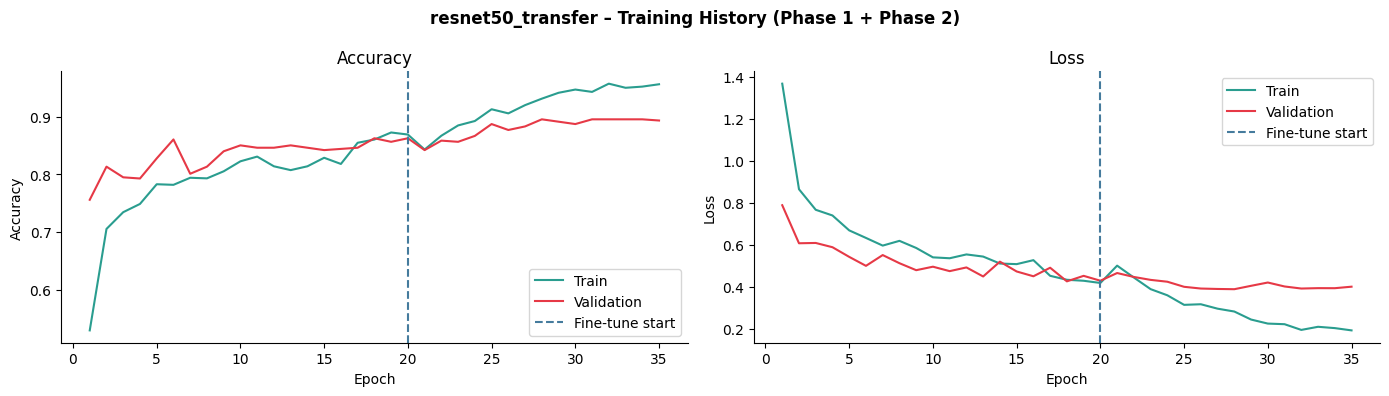

In [ ]:

def _merge_histories(h1, h2, key):
    """Concatenate phase-1 and phase-2 metric lists."""
    return h1.history[key] + h2.history[key]

p1_len = len(history_p1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"{MODEL_NAME_T} – Training History (Phase 1 + Phase 2)", fontweight="bold")

for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    train_vals = _merge_histories(history_p1, history_p2, metric)
    val_vals   = _merge_histories(history_p1, history_p2, f"val_{metric}")
    epochs_all = range(1, len(train_vals) + 1)

    ax.plot(epochs_all, train_vals, label="Train",      color="#2A9D8F")
    ax.plot(epochs_all, val_vals,   label="Validation", color="#E63946")

    # Vertical line marking phase boundary
    ax.axvline(x=p1_len, color="#457B9D", linestyle="--", linewidth=1.5, label="Fine-tune start")

    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_T}_history.png", dpi=150, bbox_inches="tight")
plt.show()

# Model Evaluation and Prediction:

Test Accuracy : 0.9147
Macro F1      : 0.9207

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.89      0.90       181
meningioma_tumor       0.89      0.85      0.87       183
          normal       0.95      0.98      0.96        88
 pituitary_tumor       0.93      0.98      0.95       169

        accuracy                           0.91       621
       macro avg       0.92      0.92      0.92       621
    weighted avg       0.91      0.91      0.91       621



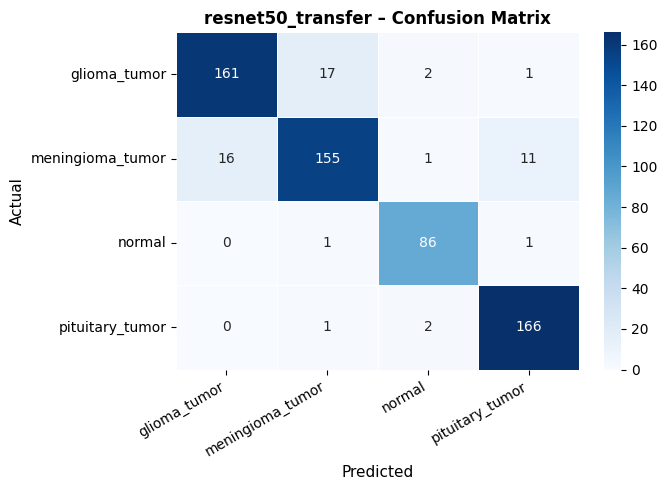

In [ ]:
# ── Predictions ───────────────────────────────────────────────
test_gen_t.reset()
y_prob_t = transfer_model.predict(test_gen_t, verbose=0)
y_pred_t = np.argmax(y_prob_t, axis=1)
y_true_t = test_gen_t.classes

acc_t = accuracy_score(y_true_t, y_pred_t)
f1_t  = f1_score(y_true_t, y_pred_t, average="macro")

# ── Metrics ───────────────────────────────────────────────────
print(f"Test Accuracy : {acc_t:.4f}")
print(f"Macro F1      : {f1_t:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_t, y_pred_t, target_names=CLASSES_T))

# ── Confusion Matrix ──────────────────────────────────────────
cm_t = confusion_matrix(y_true_t, y_pred_t)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_t,
    annot      = True,
    fmt        = "d",
    cmap       = "Blues",
    xticklabels= CLASSES_T,
    yticklabels= CLASSES_T,
    linewidths = 0.5,
    ax         = ax,
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual",    fontsize=11)
ax.set_title(f"{MODEL_NAME_T} – Confusion Matrix", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"/content/{MODEL_NAME_T}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

[glioma_tumor]  →  Predicted: glioma_tumor  (100.00%)  ✓ Correct
[meningioma_tumor]  →  Predicted: meningioma_tumor  (97.84%)  ✓ Correct
[normal]  →  Predicted: normal  (98.96%)  ✓ Correct
[pituitary_tumor]  →  Predicted: pituitary_tumor  (99.98%)  ✓ Correct


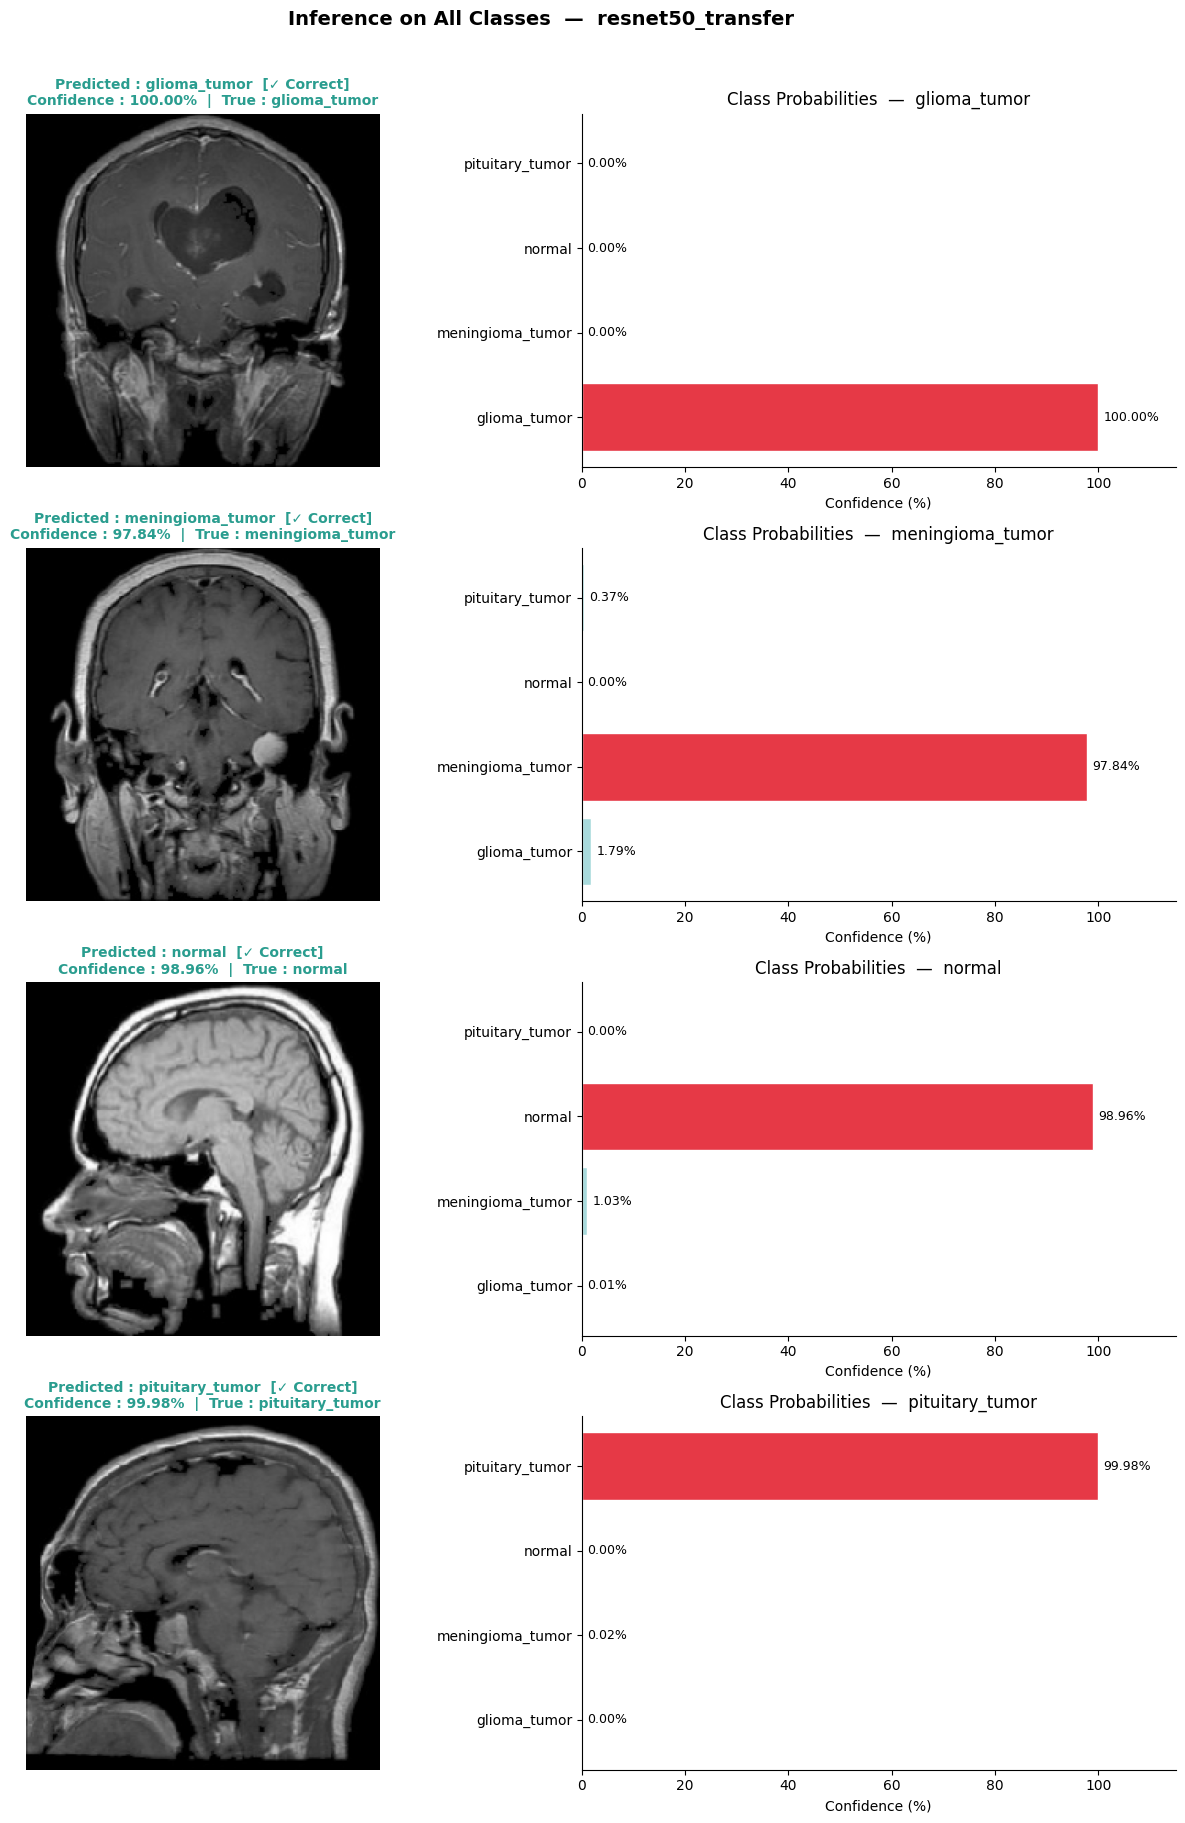


Class                Predicted              Confidence  Result
-----------------------------------------------------------------
glioma_tumor         glioma_tumor             100.00%  ✓ Correct
meningioma_tumor     meningioma_tumor          97.84%  ✓ Correct
normal               normal                    98.96%  ✓ Correct
pituitary_tumor      pituitary_tumor           99.98%  ✓ Correct


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ── Auto-pick first available image from each test class ──────
TEST_BASE = "/content/brain_tumor_data/Brain Tumor Classifcation/test"

def get_first_image(class_name):
    folder = os.path.join(TEST_BASE, class_name)
    files  = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    return os.path.join(folder, files[0]) if files else None


# ── Inference function ────────────────────────────────────────
def predict_single_image(img_path, model, classes, img_size=(224, 224)):
    img       = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_input = resnet_preprocess(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    probs      = model.predict(img_input, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_class = classes[pred_idx]
    confidence = probs[pred_idx] * 100

    true_label  = os.path.basename(os.path.dirname(img_path))
    is_correct  = (pred_class == true_label)
    result_str  = "✓ Correct" if is_correct else "✗ Wrong"
    title_color = "#2A9D8F"   if is_correct else "#E63946"

    return img, probs, pred_idx, pred_class, confidence, true_label, result_str, title_color


# ── Run inference on ALL 4 classes ───────────────────────────
all_classes = ["glioma_tumor", "meningioma_tumor", "normal", "pituitary_tumor"]
img_paths   = [get_first_image(cls) for cls in all_classes]

fig, axes = plt.subplots(4, 2, figsize=(13, 18))
fig.suptitle(f"Inference on All Classes  —  {MODEL_NAME_T}",
             fontweight="bold", fontsize=14, y=1.01)

for row, (cls, img_path) in enumerate(zip(all_classes, img_paths)):
    img, probs, pred_idx, pred_class, confidence, true_label, result_str, title_color = \
        predict_single_image(img_path, transfer_model, CLASSES_T, IMG_SIZE_T)

    # ── Left: image ───────────────────────────────────────────
    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(
        f"Predicted : {pred_class}  [{result_str}]\n"
        f"Confidence : {confidence:.2f}%  |  True : {true_label}",
        fontsize=10, color=title_color, fontweight="bold"
    )

    # ── Right: confidence bar chart ───────────────────────────
    colors = ["#E63946" if i == pred_idx else "#A8DADC" for i in range(len(CLASSES_T))]
    bars   = axes[row, 1].barh(CLASSES_T, probs * 100, color=colors, edgecolor="white")
    axes[row, 1].set_xlim(0, 115)
    axes[row, 1].set_xlabel("Confidence (%)")
    axes[row, 1].set_title(f"Class Probabilities  —  {cls}")
    axes[row, 1].spines[["top", "right"]].set_visible(False)

    for bar, prob in zip(bars, probs):
        axes[row, 1].text(
            bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{prob*100:.2f}%", va="center", fontsize=9
        )

    # ── Console row ───────────────────────────────────────────
    print(f"[{cls}]  →  Predicted: {pred_class}  ({confidence:.2f}%)  {result_str}")

plt.tight_layout()
plt.savefig("/content/inference_all_classes.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Final console summary table ───────────────────────────────
print(f"\n{'Class':<20} {'Predicted':<20} {'Confidence':>12}  {'Result'}")
print("-" * 65)
for cls, img_path in zip(all_classes, img_paths):
    _, probs, pred_idx, pred_class, confidence, _, result_str, _ = \
        predict_single_image(img_path, transfer_model, CLASSES_T, IMG_SIZE_T)
    print(f"{cls:<20} {pred_class:<20} {confidence:>10.2f}%  {result_str}")

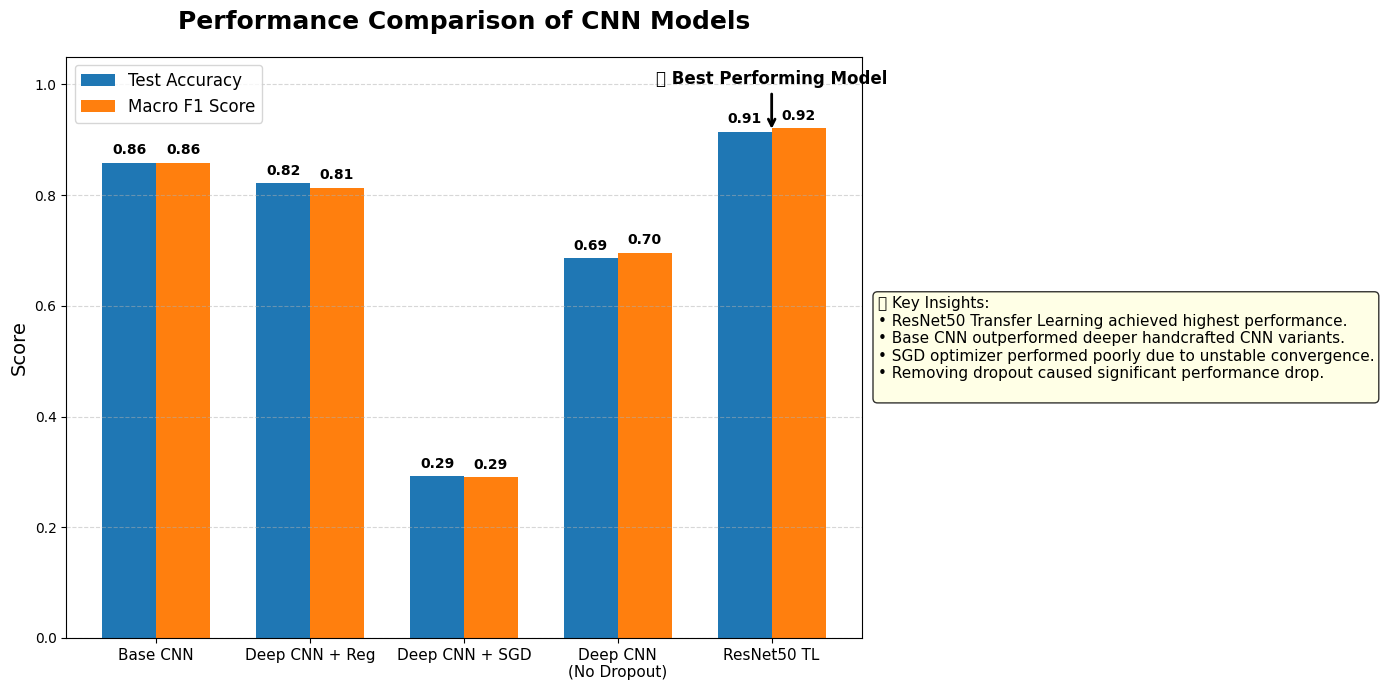

In [ ]:
# ============================================================
# 📊 CNN MODEL PERFORMANCE COMPARISON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 🧠 Model Names
# ------------------------------------------------------------

models = [
    "Base CNN",
    "Deep CNN + Reg",
    "Deep CNN + SGD",
    "Deep CNN\n(No Dropout)",
    "ResNet50 TL"
]

# ------------------------------------------------------------
# 📈 Main Evaluation Metrics
# ------------------------------------------------------------

accuracy = [0.8583, 0.8213, 0.2916, 0.6860, 0.9147]
macro_f1 = [0.8587, 0.8137, 0.2900, 0.6955, 0.9207]

# ------------------------------------------------------------
# 🎨 Bar Positions
# ------------------------------------------------------------

x = np.arange(len(models))
width = 0.35

# ------------------------------------------------------------
# 🖼️ Create Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

# Accuracy Bars
bars1 = ax.bar(
    x - width/2,
    accuracy,
    width,
    label='Test Accuracy'
)

# F1 Score Bars
bars2 = ax.bar(
    x + width/2,
    macro_f1,
    width,
    label='Macro F1 Score'
)

# ------------------------------------------------------------
# ✨ Add Value Labels on Top
# ------------------------------------------------------------

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# ------------------------------------------------------------
# 🧾 Graph Styling
# ------------------------------------------------------------

ax.set_title(
    "Performance Comparison of CNN Models",
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_ylabel("Score", fontsize=14)
ax.set_ylim(0, 1.05)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

ax.legend(fontsize=12)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# ------------------------------------------------------------
# 🏆 Highlight Best Model
# ------------------------------------------------------------

best_idx = np.argmax(accuracy)

ax.annotate(
    '🏆 Best Performing Model',
    xy=(best_idx, accuracy[best_idx]),
    xytext=(best_idx, 1.0),
    arrowprops=dict(arrowstyle='->', lw=2),
    fontsize=12,
    ha='center',
    fontweight='bold'
)

# ------------------------------------------------------------
# 📦 Summary Box
# ------------------------------------------------------------

summary_text = (
    "📌 Key Insights:\n"
    "• ResNet50 Transfer Learning achieved highest performance.\n"
    "• Base CNN outperformed deeper handcrafted CNN variants.\n"
    "• SGD optimizer performed poorly due to unstable convergence.\n"
    "• Removing dropout caused significant performance drop.\n"
)

props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)

ax.text(
    1.02,
    0.5,
    summary_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='center',
    bbox=props
)

# ------------------------------------------------------------
# 🚀 Show Plot
# ------------------------------------------------------------

plt.tight_layout()
plt.show()